# I-Environnement


## 1-Environnement & imports

In [66]:
# ============================================================
# STEP 1 — Environnement
# ============================================================
import os, math, time, csv
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import (resnet18, resnet50,
                                 ResNet18_Weights, ResNet50_Weights)
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score)
import yaml

# — Hardware —
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"GPUs disponibles : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i} : {torch.cuda.get_device_name(i)} "
          f"— {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
GPUs disponibles : 2
  GPU 0 : Tesla T4 — 15.6 GB
  GPU 1 : Tesla T4 — 15.6 GB
PyTorch : 2.10.0+cu128


## 2-Config YAML + Struct 

In [67]:
# ============================================================
# STEP 2 — Config
# Coller ici le YAML du dataset courant.
# Ce bloc est identique à celui du notebook dataset correspondant.
# Pour changer de dataset : remplacer le YAML + la classe Dataset
# (cellule 3) par ceux du nouveau dataset.
# ============================================================
import yaml

# — Exemple : NODE21 —
NODE21_CONFIG = """

# optimisation
n_epoch: 50
B: 16                  # batch size
B_seq: 16              # sequential batch size
n_epoch_warmup: 5
lr: 0.0001
wd: 0.1

# dataset
n_class: 2
data_dir: '/kaggle/input/datasets/pshikk/node-21-dataset-untampered'
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 0
track_epochs: [0, 1]

# encodeur
is_image: True
enc_type: 'resnet18'
pretrained: True
n_chan_in: 1           # grayscale
n_res_blocks: 4

# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
N: 64                  # 1024/128 × 1024/128 = 64 patches
M: 10                  # patches sélectionnés
I: 16                  # patches par itération
patch_size: [128, 128]
patch_stride: [128, 128]

# agrégateur
use_pos: False
H: 8
D: 512
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'nodule'
    act_fn: 'softmax'
    metric:
      - accuracy
      - auc
      - f1
      - precision
      - recall
"""

class Struct:
    def __init__(self, **entries):
        self.__dict__.update(entries)

node21_conf = Struct(**yaml.safe_load(NODE21_CONFIG))

# — Vérification —
print(f"Dataset     : {node21_conf.data_dir}")
print(f"n_epoch     : {node21_conf.n_epoch}")
print(f"M={node21_conf.M}, I={node21_conf.I}, D={node21_conf.D}")
print(f"Tasks       : {[t['name'] for t in node21_conf.tasks.values()]}")

Dataset     : /kaggle/input/datasets/pshikk/node-21-dataset-untampered
n_epoch     : 50
M=10, I=16, D=512
Tasks       : ['nodule']


#  config Luna 16

In [68]:
# ============================================================
# STEP 1 — Config LUNA16
# ============================================================

LUNA16_CONFIG = """
# optimisation
n_epoch: 50
B: 16
B_seq: 1
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 2
data_dir: '/kaggle/input/datasets/tandem03/luna16-byol-features'
train_fname: 'features_train_fold0.h5'
test_fname: 'features_test_fold0.h5'
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 0
track_epochs: [0, 1]

# encodeur — features pré-extraites, pas d'encodeur convolutif
is_image: False
enc_type: 'resnet50'
pretrained: False
n_chan_in: 2048        # dim features BYOL
n_res_blocks: 4

# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
N: 5068                # patches/scan (moyenne train)
M: 10
I: 16
patch_size: [64, 64]
patch_stride: [64, 64]

# agrégateur
use_pos: False
H: 8
D: 512
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'nodule'
    act_fn: 'softmax'
    metric:
      - accuracy
      - auc
      - f1
      - precision
      - recall
"""

luna16_conf = Struct(**yaml.safe_load(LUNA16_CONFIG))

print(f"Dataset     : {luna16_conf.data_dir}")
print(f"is_image    : {luna16_conf.is_image}")
print(f"n_chan_in   : {luna16_conf.n_chan_in}  (features 2048D)")
print(f"N={luna16_conf.N}, M={luna16_conf.M}, I={luna16_conf.I}, D={luna16_conf.D}")
print(f"Tasks       : {[t['name'] for t in luna16_conf.tasks.values()]}")

Dataset     : /kaggle/input/datasets/tandem03/luna16-byol-features
is_image    : False
n_chan_in   : 2048  (features 2048D)
N=5068, M=10, I=16, D=512
Tasks       : ['nodule']


# DDR

In [69]:
import yaml

DDR_CONFIG = """
# optimisation
n_epoch: 250
B: 16                   # batch effectif réduit (16→8)
B_seq: 16               # séquentiel réduit (16→4) — levier principal OOM
n_epoch_warmup: 5
lr: 0.0001
wd: 0.1

# dataset
n_class: 5
data_dir: '/kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset'
n_worker: 4
pin_memory: True
eager: True           # False = patches restent CPU jusqu'au .ips() → économise VRAM

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# encodeur
is_image: True
enc_type: 'resnet18'
pretrained: True
n_chan_in: 3
n_res_blocks: 4       # ResNet50 full → 2048 features

# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
N: 49
M: 10                   # patches sélectionnés réduits (10→7)
I: 10                  # patches par itération réduits (16→10)
patch_size: [128, 128]
patch_stride: [128, 128]

# agrégateur
use_pos: False
H: 8
D: 512                # doit matcher ResNet50 output
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'dr_grade'
    act_fn: 'softmax'
    metric:
      - accuracy
      - kappa
      - f1
"""

class Struct:
    def __init__(self, **entries):
        self.__dict__.update(entries)

ddr_conf = Struct(**yaml.safe_load(DDR_CONFIG))

print(f"Dataset  : {ddr_conf.data_dir}")
print(f"n_class  : {ddr_conf.n_class}")
print(f"Tasks    : {[t['name'] for t in ddr_conf.tasks.values()]}")
print(f"Métriques: {ddr_conf.tasks['task0']['metric']}")

Dataset  : /kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset
n_class  : 5
Tasks    : ['dr_grade']
Métriques: ['accuracy', 'kappa', 'f1']


# II-Dataset

## 1-Dataset Instance

## a-NODE21Dataset

In [70]:
# ============================================================
# Cellule 3 — Dataset : NODE21Dataset
# Copié depuis dataset_node21.ipynb — fond inchangé
# ============================================================
import os
import numpy as np
import torch
import SimpleITK as sitk
import hashlib
from pathlib import Path
from torch.utils.data import Dataset
from torchvision import transforms

class NODE21Dataset(Dataset):
    """
    Classification binaire : nodule présent (1) ou absent (0).
    Positifs : proccessed_data/images/n*.mha  (uint16, preprocessées)
    Négatifs : original_data/images/c*.mha    (uint8, sans nodule simulé)
    Split train/test reproductible par hash sur le nom de fichier.
    """

    CLASSES  = ['no_nodule', 'nodule']
    IMG_SIZE = 1024

    @staticmethod
    def _to_split(name, seed=42):
        h = int(hashlib.md5((name + str(seed)).encode()).hexdigest(), 16)
        return 'test' if (h % 100) < 20 else 'train'

    def __init__(self, conf, train=True):
        self.patch_size   = conf.patch_size
        self.patch_stride = conf.patch_stride
        self.tasks        = conf.tasks

        data_root = Path(conf.data_dir)
        proc_dir  = data_root / 'cxr_images' / 'proccessed_data' / 'images'
        orig_dir  = data_root / 'cxr_images' / 'original_data'   / 'images'

        all_samples = (
            [(f, 1) for f in sorted(proc_dir.glob('n*.mha'))] +
            [(f, 0) for f in sorted(orig_dir.glob('c*.mha'))]
        )

        split_name = 'train' if train else 'test'
        self._data = [
            (path, label) for path, label in all_samples
            if self._to_split(path.name) == split_name
        ]

        if train:
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(5),
                transforms.Normalize(mean=[0.5], std=[0.5])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Normalize(mean=[0.5], std=[0.5])
            ])

        print(f"{'Train' if train else 'Test'} : {len(self._data)} images "
              f"(pos={sum(l for _,l in self._data)}, "
              f"neg={sum(1-l for _,l in self._data)})")

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        path, label = self._data[i]

        arr = sitk.GetArrayFromImage(
            sitk.ReadImage(str(path))).astype(np.float32)

        # Redimensionner à 1024×1024 si nécessaire
        if arr.shape != (self.IMG_SIZE, self.IMG_SIZE):
            from PIL import Image as PILImage
            pil = PILImage.fromarray(
                ((arr - arr.min()) / (arr.max() - arr.min() + 1e-6) * 255)
                .astype(np.uint8)
            ).resize((self.IMG_SIZE, self.IMG_SIZE), PILImage.BILINEAR)
            arr = np.array(pil, dtype=np.float32) / 255.0
        else:
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)

        # [H, W] → tensor [1, H, W]
        img = torch.from_numpy(arr).unsqueeze(0)
        img = self.transform(img)

        # Extraire les patches
        ps, stride = self.patch_size, self.patch_stride
        patches = img.unfold(1, ps[0], stride[0]) \
                     .unfold(2, ps[1], stride[1]) \
                     .permute(1, 2, 0, 3, 4)
        patches = patches.reshape(-1, *patches.shape[2:])

        data_dict = {'input': patches}
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict


# ── Sanity check ────────────────────────────────────────────
ds     = NODE21Dataset(node21_conf, train=True)
sample = ds[0]
print(f"Input shape : {sample['input'].shape}")   # attendu : (64, 1, 128, 128)
print(f"Label       : {sample['nodule']}")         # attendu : 0 ou 1

Train : 3902 images (pos=915, neg=2987)
Input shape : torch.Size([64, 1, 128, 128])
Label       : 1


# LunaFeatures Dataset

In [71]:
# ============================================================
# STEP 2 — LunaFeatures Dataset
# ============================================================
import os
import numpy as np
import torch
import h5py
from torch.utils.data import Dataset


class LunaFeatures(Dataset):
    """
    Charge les features pré-extraites depuis HDF5.
    Structure : un groupe par scan, dataset 'img' (N_patches, 2048) float16,
    attribut 'label' (0 ou 1).
    """

    def __init__(self, conf, train=True):
        self.tasks    = conf.tasks
        fname         = conf.train_fname if train else conf.test_fname
        self.filepath = os.path.join(conf.data_dir, fname)
        self.dataset  = None   # ouvert en lazy dans __getitem__

        # Lire les clés sans garder le fichier ouvert
        with h5py.File(self.filepath, 'r') as f:
            self.scan_names = list(f.keys())

        split = 'Train' if train else 'Test'
        pos   = 0
        with h5py.File(self.filepath, 'r') as f:
            for name in self.scan_names:
                if f[name].attrs['label'] == 1:
                    pos += 1
        neg = len(self.scan_names) - pos
        print(f"{split} : {len(self.scan_names)} scans  "
              f"(pos={pos}, neg={neg})")

    def __len__(self):
        return len(self.scan_names)

    def _open(self):
        """Ouverture lazy — une seule fois par worker."""
        if self.dataset is None:
            self.dataset = h5py.File(self.filepath, 'r')

    def __getitem__(self, i):
        self._open()
        scan  = self.dataset[self.scan_names[i]]
        # float16 → float32 pour PyTorch
        feats = torch.from_numpy(
            scan['img'][:].astype(np.float32))   # (N_patches, 2048)
        label = int(scan.attrs['label'])

        data_dict = {'input': feats}
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict


# DDRdataset

In [72]:
# ============================================================
# Cellule 3 — Dataset : DDRDataset
# Classification DR à 5 classes (0→4), classe 5 exclue.
# Split : dossiers train/valid/test fournis par DDR.
# Input : images .jpg RGB, resize 896×896, patches 128×128.
# ============================================================
import os
import numpy as np
import torch
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


class DDRDataset(Dataset):
    """
    Dataset DDR — rétinopathie diabétique, 5 classes (0→4).

    Structure attendue :
        data_dir/
          DR_grading/
            train/  (images .jpg)
            valid/
            test/
            train.txt  (une ligne par image : "nom.jpg grade")
            valid.txt
            test.txt

    Classe 5 (ungradable) exclue automatiquement.
    Split : 'train' → dossier train  |  'valid' → dossier valid
            'test'  → dossier test   |  train=True → train, train=False → valid
    """

    CLASSES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
    IMG_SIZE = 896   # → 7×7 patches de 128×128 = 49 patches

    def __init__(self, conf, train=True, split=None):
        """
        Args:
            conf  : objet Struct avec data_dir, patch_size, patch_stride, tasks
            train : si split=None, True → 'train', False → 'valid'
            split : forcer 'train' | 'valid' | 'test'
        """
        self.patch_size   = conf.patch_size    # [128, 128]
        self.patch_stride = conf.patch_stride  # [128, 128]
        self.tasks        = conf.tasks
        self.img_size     = self.IMG_SIZE

        if split is None:
            split = 'train' if train else 'valid'
        assert split in ('train', 'valid', 'test'), \
            f"split doit être 'train', 'valid' ou 'test', reçu: {split}"
        self.split = split

        data_root   = Path(conf.data_dir) / 'DR_grading'
        label_file  = data_root / f'{split}.txt'
        img_dir     = data_root / split

        # ── Lecture des labels ────────────────────────────────
        self._data = []
        with open(label_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                fname, grade = parts[0], int(parts[1])
                if grade == 5:          # exclure ungradable
                    continue
                img_path = img_dir / fname
                if img_path.exists():
                    self._data.append((img_path, grade))

        # ── Distribution ─────────────────────────────────────
        counts = [0] * 5
        for _, g in self._data:
            counts[g] += 1
        dist_str = ', '.join(
            f"C{i}={counts[i]}" for i in range(5))
        print(f"[DDRDataset] split={split:5s} | {len(self._data):5d} imgs | {dist_str}")

        # ── Transforms ───────────────────────────────────────
        if split == 'train':
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(
                    brightness=0.2, contrast=0.2,
                    saturation=0.1, hue=0.05),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self._data)

    def _load_image(self, path):
        """Charge, resize en 896×896, convertit en tensor [3, H, W] float32."""
        img = Image.open(path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0   # [H, W, 3]
        return torch.from_numpy(arr).permute(2, 0, 1)    # [3, H, W]

    def __getitem__(self, i):
        path, label = self._data[i]

        img = self._load_image(path)         # [3, H, W]
        img = self.transform(img)

        # ── Extraction des patches ────────────────────────────
        # img : [3, 896, 896]  →  patches : [N, 3, 128, 128]
        ps, stride = self.patch_size, self.patch_stride
        patches = img.unfold(1, ps[0], stride[0]) \
                     .unfold(2, ps[1], stride[1]) \
                     .permute(1, 2, 0, 3, 4)      # [n_row, n_col, 3, ph, pw]
        patches = patches.reshape(-1, *patches.shape[2:])  # [N, 3, 128, 128]

        data_dict = {'input': patches}
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict


# ── Sanity check ─────────────────────────────────────────────
ds_train = DDRDataset(ddr_conf, train=True)
ds_val   = DDRDataset(ddr_conf, train=False)
ds_test  = DDRDataset(ddr_conf, split='test')

sample = ds_train[0]
print(f"\nInput shape  : {sample['input'].shape}")   # attendu : (49, 3, 128, 128)
print(f"Label        : {sample['dr_grade']}")        # attendu : 0–4
print(f"N patches    : {sample['input'].shape[0]}")  # attendu : 49

# Vérifier quelques labels pour confirmer l'exclusion de la classe 5
labels_train = [ds_train[i]['dr_grade'] for i in range(min(200, len(ds_train)))]
print(f"Labels uniques (train, 200 premiers) : {sorted(set(labels_train))}")

[DDRDataset] split=train |  6260 imgs | C0=3133, C1=315, C2=2238, C3=118, C4=456
[DDRDataset] split=valid |  2503 imgs | C0=1253, C1=126, C2=895, C3=47, C4=182
[DDRDataset] split=test  |  3759 imgs | C0=1880, C1=189, C2=1344, C3=71, C4=275

Input shape  : torch.Size([49, 3, 128, 128])
Label        : 0
N patches    : 49
Labels uniques (train, 200 premiers) : [0]


## 2- DataFactory

In [73]:
class DataFactory:
    """
    Instancie train/test datasets et dataloaders.

    Usage :
        factory = DataFactory(node21_conf, dataset="node21")
        train_loader, test_loader = factory.loaders()

    Pour changer de dataset : remplacer conf + dataset="luna" etc.
    """

    # Registre : nom → classe Dataset
    _registry = {
        "node21":  NODE21Dataset,
        # Décommenter quand les classes sont définies :
        # "camelyon": CamelyonFeatures,
        "luna16":     LunaFeatures,
        # "lungct":   LungCTFeatures,
        # "mnist":    MegapixelMNIST,
        # "traffic":  TrafficSigns,
    }

    def __init__(self, conf, dataset="node21"):
        if dataset not in self._registry:
            raise ValueError(
                f"Dataset '{dataset}' inconnu. "
                f"Disponibles : {list(self._registry.keys())}")

        self.conf    = conf
        self.dataset = dataset
        cls          = self._registry[dataset]

        self.train_data = cls(conf, train=True)
        self.test_data  = cls(conf, train=False)

    def loaders(self):
        conf = self.conf
        train_loader = DataLoader(
            self.train_data,
            batch_size=conf.B_seq,
            shuffle=True,
            num_workers=conf.n_worker,
            pin_memory=conf.pin_memory,
            persistent_workers=True
        )
        test_loader = DataLoader(
            self.test_data,
            batch_size=conf.B_seq,
            shuffle=False,
            num_workers=conf.n_worker,
            pin_memory=conf.pin_memory,
            persistent_workers=True
        )
        return train_loader, test_loader

# III-Architecture

In [74]:
# ============================================================
# Cellule 4 — Architecture
# pos_enc_1d → ScaledDotProductAttention → MultiHeadCrossAttention
# → MLP → Transformer → IPSNet
# Fond inchangé — mise en forme uniquement
# ============================================================
import math
import torch
import torch.nn as nn
from torchvision.models import resnet18, resnet50, ResNet18_Weights, ResNet50_Weights


def pos_enc_1d(D, len_seq):

    if D % 2 != 0:
        raise ValueError("Cannot use sin/cos positional encoding with "
                         "odd dim (got dim={:d})".format(D))
    pe = torch.zeros(len_seq, D)
    position = torch.arange(0, len_seq).unsqueeze(1)
    div_term = torch.exp((torch.arange(0, D, 2, dtype=torch.float) *
                         -(math.log(10000.0) / D)))
    pe[:, 0::2] = torch.sin(position.float() * div_term)
    pe[:, 1::2] = torch.cos(position.float() * div_term)

    return pe


class ScaledDotProductAttention(nn.Module):
    """Dot-Product Attention"""

    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout     = nn.Dropout(attn_dropout)

    def compute_attn(self, q, k):
        attn = torch.matmul(q / self.temperature, k.transpose(2, 3))
        attn = self.dropout(torch.softmax(attn, dim=-1))
        return attn

    def forward(self, q, k, v):
        attn   = self.compute_attn(q, k)
        output = torch.matmul(attn, v)
        return output


class MultiHeadCrossAttention(nn.Module):
    """Multi-head cross-attention module"""

    def __init__(self, n_token, H, D, D_k, D_v, attn_dropout=0.1, dropout=0.1):
        super().__init__()
        self.n_token = n_token
        self.H       = H
        self.D_k     = D_k
        self.D_v     = D_v

        self.q = nn.Parameter(torch.empty((1, n_token, D)))
        nn.init.uniform_(self.q, a=-math.sqrt(1 / D_k), b=math.sqrt(1 / D_k))

        self.q_w = nn.Linear(D, H * D_k, bias=False)
        self.k_w = nn.Linear(D, H * D_k, bias=False)
        self.v_w = nn.Linear(D, H * D_v, bias=False)
        self.fc  = nn.Linear(H * D_v, D, bias=False)

        self.attention  = ScaledDotProductAttention(
            temperature=D_k ** 0.5, attn_dropout=attn_dropout)
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(D, eps=1e-6)

    def get_attn(self, x):
        D_k, H, n_token = self.D_k, self.H, self.n_token
        B, len_seq = x.shape[:2]
        q = self.q_w(self.q).view(1, n_token, H, D_k)
        k = self.k_w(x).view(B, len_seq, H, D_k)
        q, k = q.transpose(1, 2), k.transpose(1, 2)
        return self.attention.compute_attn(q, k)

    def forward(self, x):
        D_k, D_v, H, n_token = self.D_k, self.D_v, self.H, self.n_token
        B, len_seq = x.shape[:2]
        q = self.q_w(self.q).view(1, n_token, H, D_k)
        k = self.k_w(x).view(B, len_seq, H, D_k)
        v = self.v_w(x).view(B, len_seq, H, D_v)
        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)
        x = self.attention(q, k, v)
        x = x.transpose(1, 2).contiguous().view(B, n_token, -1)
        x = self.dropout(self.fc(x))
        x += self.q
        x = self.layer_norm(x)
        return x


class MLP(nn.Module):
    """MLP composé de deux couches feed-forward"""

    def __init__(self, D, D_inner, dropout=0.1):
        super().__init__()
        self.w_1        = nn.Linear(D, D_inner)
        self.w_2        = nn.Linear(D_inner, D)
        self.layer_norm = nn.LayerNorm(D, eps=1e-6)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.w_2(torch.relu(self.w_1(x)))
        x = self.dropout(x)
        x += residual
        x = self.layer_norm(x)
        return x


class Transformer(nn.Module):
    """Transformer basé sur le cross-attention"""

    def __init__(self, n_token, H, D, D_k, D_v, D_inner,
                 attn_dropout=0.1, dropout=0.1):
        super().__init__()
        self.crs_attn = MultiHeadCrossAttention(
            n_token, H, D, D_k, D_v,
            attn_dropout=attn_dropout, dropout=dropout)
        self.mlp = MLP(D, D_inner, dropout=dropout)

    def get_scores(self, x):
        attn = self.crs_attn.get_attn(x)
        return attn.mean(dim=1).transpose(1, 2).mean(-1)

    def forward(self, x):
        return self.mlp(self.crs_attn(x))


class IPSNet(nn.Module):
    """
    Modèle principal : encodeur de patches, IPS,
    agrégateur et tête de classification.
    """

    def get_conv_patch_enc(self, enc_type, pretrained, n_chan_in, n_res_blocks):
        if enc_type == 'resnet18':
            res_net_fn = resnet18
            imagenet_weights = ResNet18_Weights.IMAGENET1K_V1
        elif enc_type == 'resnet50':
            res_net_fn = resnet50
            imagenet_weights = ResNet50_Weights.IMAGENET1K_V1
        else:
            raise ValueError(f"enc_type inconnu : {enc_type}")
    
        # -- Cas 1 : True → ImageNet (rétro-compatibilité) --
        if pretrained is True:
            res_net = res_net_fn(weights=imagenet_weights)
            print(f"[Encoder] ImageNet ({enc_type})")
    
        # -- Cas 2 : None/False → poids aléatoires --
        elif pretrained is None or pretrained is False:
            res_net = res_net_fn(weights=None)
            print(f"[Encoder] Poids aléatoires ({enc_type})")
    
        # -- Cas 3 : objet Weights torchvision (ResNet18_Weights.*, ResNet50_Weights.*, etc.) --
        elif hasattr(pretrained, 'url') or hasattr(pretrained, 'value'):
            res_net = res_net_fn(weights=pretrained)
            print(f"[Encoder] Weights torchvision : {pretrained}")
    
        # -- Cas 4 : chemin .pt → state_dict (tes propres poids, MedNet, RadImageNet...) --
        elif isinstance(pretrained, str):
            res_net = res_net_fn(weights=None)
            state   = torch.load(pretrained, map_location='cpu', weights_only=True)
            # Accepte un state_dict brut ou un checkpoint avec clé 'model_state'
            if isinstance(state, dict) and 'model_state' in state:
                state = state['model_state']
            missing, unexpected = res_net.load_state_dict(state, strict=False)
            print(f"[Encoder] Poids depuis {pretrained}")
            if missing:
                print(f"  Manquants  : {len(missing)} clés")
            if unexpected:
                print(f"  Inattendus : {len(unexpected)} clés")
    
        else:
            raise ValueError(
                f"pretrained='{pretrained}' non reconnu.\n"
                "Attendu : True | None | False | "
                "ResNet18_Weights.* | '/path/to/weights.pt'")
    
        # -- Adaptation canal d'entrée --
        if n_chan_in != 3:
            old_conv = res_net.conv1
            res_net.conv1 = nn.Conv2d(
                n_chan_in, 64, kernel_size=7,
                stride=2, padding=3, bias=False)
            # Si préentraîné + grayscale : moyenne RGB → 1 canal
            if pretrained is not None and pretrained is not False:
                res_net.conv1.weight.data = \
                    old_conv.weight.data.mean(dim=1, keepdim=True)
    
        layer_ls = [
            res_net.conv1, res_net.bn1, res_net.relu,
            res_net.maxpool, res_net.layer1, res_net.layer2
        ]
        if n_res_blocks == 4:
            layer_ls.extend([res_net.layer3, res_net.layer4])
        layer_ls.append(res_net.avgpool)
    
        return nn.Sequential(*layer_ls)

    def get_projector(self, n_chan_in, D):
        return nn.Sequential(
            nn.LayerNorm(n_chan_in, eps=1e-05, elementwise_affine=False),
            nn.Linear(n_chan_in, D),
            nn.BatchNorm1d(D),
            nn.ReLU()
        )

    def get_output_layers(self, tasks):
        D       = self.D
        n_class = self.n_class
        output_layers = nn.ModuleDict()
        for task in tasks.values():
            act_fn = (nn.Softmax(dim=-1) if task['act_fn'] == 'softmax'
                      else nn.Sigmoid())
            output_layers[task['name']] = nn.Sequential(
                nn.Linear(D, n_class), act_fn)
        return output_layers

    def __init__(self, device, conf):
        super().__init__()
        self.device       = device
        self.n_class      = conf.n_class
        self.M            = conf.M
        self.I            = conf.I
        self.D            = conf.D
        self.use_pos      = conf.use_pos
        self.tasks        = conf.tasks
        self.shuffle      = conf.shuffle
        self.shuffle_style= conf.shuffle_style
        self.is_image     = conf.is_image

        if self.is_image:
            self.encoder = self.get_conv_patch_enc(
                conf.enc_type, conf.pretrained,
                conf.n_chan_in, conf.n_res_blocks)
        else:
            self.encoder = self.get_projector(conf.n_chan_in, self.D)

        self.transf = Transformer(
            conf.n_token, conf.H, conf.D, conf.D_k, conf.D_v,
            conf.D_inner, conf.attn_dropout, conf.dropout)

        if conf.use_pos:
            self.pos_enc = pos_enc_1d(conf.D, conf.N).unsqueeze(0).to(device)
        else:
            self.pos_enc = None

        self.output_layers = self.get_output_layers(conf.tasks)

    def do_shuffle(self, patches, pos_enc):
        if self.shuffle_style == 'batch':
            patches, shuffle_idx = shuffle_batch(patches)
            if torch.is_tensor(pos_enc):
                pos_enc, _ = shuffle_batch(pos_enc, shuffle_idx)
        elif self.shuffle_style == 'instance':
            patches, shuffle_idx = shuffle_instance(patches, 1)
            if torch.is_tensor(pos_enc):
                pos_enc, _ = shuffle_instance(pos_enc, 1, shuffle_idx)
        return patches, pos_enc

    def score_and_select(self, emb, emb_pos, M, idx):
        D       = emb.shape[2]
        emb_to_score = emb_pos if torch.is_tensor(emb_pos) else emb
        attn    = self.transf.get_scores(emb_to_score)
        top_idx = torch.topk(attn, M, dim=-1)[1]
        mem_emb = torch.gather(emb, 1,
            top_idx.unsqueeze(-1).expand(-1, -1, D))
        mem_idx = torch.gather(idx, 1, top_idx)
        return mem_emb, mem_idx

    def get_preds(self, embeddings):
        preds = {}
        for task in self.tasks.values():
            t_name, t_id = task['name'], task['id']
            preds[t_name] = self.output_layers[t_name](embeddings[:, t_id])
        return preds

    def ips(self, patches):
        """Iterative Patch Selection"""
        M, I, D   = self.M, self.I, self.D
        device    = self.device
        use_pos   = self.use_pos
        pos_enc   = self.pos_enc
        patch_shape = patches.shape
        B, N      = patch_shape[:2]

        # Raccourci : IPS inutile si M >= N
        if M >= N:
            pos_enc = pos_enc.expand(B, -1, -1) if use_pos else None
            return patches.to(device), pos_enc

        # IPS en mode évaluation
        if self.training:
            self.encoder.eval()
            self.transf.eval()

        if use_pos:
            pos_enc = pos_enc.expand(B, -1, -1)

        if self.shuffle:
            patches, pos_enc = self.do_shuffle(patches, pos_enc)

        # Initialisation du buffer mémoire
        init_patch = patches[:, :M].to(device)
        mem_emb = self.encoder(init_patch.reshape(-1, *patch_shape[2:]))
        mem_emb = mem_emb.view(B, M, -1)

        idx     = torch.arange(N, dtype=torch.int64, device=device) \
                      .unsqueeze(0).expand(B, -1)
        mem_idx = idx[:, :M]

        # Boucle IPS
        n_iter = math.ceil((N - M) / I)
        for i in range(n_iter):
            start_idx = i * I + M
            end_idx   = min(start_idx + I, N)

            iter_patch = patches[:, start_idx:end_idx].to(device)
            iter_idx   = idx[:, start_idx:end_idx]

            iter_emb = self.encoder(
                iter_patch.reshape(-1, *patch_shape[2:]))
            iter_emb = iter_emb.view(B, -1, D)

            all_emb = torch.cat((mem_emb, iter_emb), dim=1)
            all_idx = torch.cat((mem_idx, iter_idx), dim=1)

            if use_pos:
                all_pos_enc = torch.gather(
                    pos_enc, 1,
                    all_idx.view(B, -1, 1).expand(-1, -1, D))
                all_emb_pos = all_emb + all_pos_enc
            else:
                all_emb_pos = None

            mem_emb, mem_idx = self.score_and_select(
                all_emb, all_emb_pos, M, all_idx)

        # Sélection des patches finaux
        n_dim_expand = len(patch_shape) - 2
        mem_patch = torch.gather(
            patches, 1,
            mem_idx.view(B, -1, *(1,)*n_dim_expand)
                   .expand(-1, -1, *patch_shape[2:])
                   .to(patches.device)
        ).to(device)

        if use_pos:
            mem_pos = torch.gather(
                pos_enc, 1,
                mem_idx.unsqueeze(-1).expand(-1, -1, D))
        else:
            mem_pos = None

        # Retour en mode entraînement
        if self.training:
            self.encoder.train()
            self.transf.train()

        return mem_patch, mem_pos

    def forward(self, mem_patch, mem_pos=None):
        """
        Re-encode et agrège les M patches sélectionnés,
        puis classifie l'embedding agrégé.
        """
        patch_shape = mem_patch.shape
        B, M        = patch_shape[:2]

        mem_emb = self.encoder(
            mem_patch.reshape(-1, *patch_shape[2:]))
        mem_emb = mem_emb.view(B, M, -1)

        if torch.is_tensor(mem_pos):
            mem_emb = mem_emb + mem_pos

        image_emb = self.transf(mem_emb)
        preds     = self.get_preds(image_emb)
        return preds


# ── Vérification ────────────────────────────────────────────
net      = IPSNet(DEVICE, node21_conf)
n_params = sum(p.numel() for p in net.parameters()) / 1e6
print(f"Params : {n_params:.3f} M")

[Encoder] ImageNet (resnet18)
Params : 14.322 M


# IV- utils/ helper

In [75]:
# ============================================================
# Cellule 5a — Logger + fonctions utilitaires
# Copié depuis utils/utils.py — fond inchangé
# ============================================================
import math
import numpy as np
from collections import defaultdict
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score)
import torch
import torch.nn as nn


def adjust_learning_rate(n_epoch_warmup, n_epoch, max_lr,
                         optimizer, dloader, step):
    """Ajuste le learning rate selon un schedule cosinus avec warmup."""
    max_steps    = int(n_epoch * len(dloader))
    warmup_steps = int(n_epoch_warmup * len(dloader))

    if step < warmup_steps:
        lr = max_lr * step / warmup_steps
    else:
        step      -= warmup_steps
        max_steps -= warmup_steps
        q          = 0.5 * (1 + math.cos(math.pi * step / max_steps))
        end_lr     = max_lr * 0.001
        lr         = max_lr * q + end_lr * (1 - q)

    optimizer.param_groups[0]['lr'] = lr


def shuffle_batch(x, shuffle_idx=None):
    """Mélange chaque instance du batch de la même façon."""
    if not torch.is_tensor(shuffle_idx):
        seq_len     = x.shape[1]
        shuffle_idx = torch.randperm(seq_len)
    x = x[:, shuffle_idx]
    return x, shuffle_idx


def shuffle_instance(x, axis, shuffle_idx=None):
    """Mélange chaque instance du batch différemment."""
    if not torch.is_tensor(shuffle_idx):
        shuffle_idx = torch.rand(
            x.shape[:axis+1], device=x.device).argsort(axis)

    idx_expand = shuffle_idx.clone().to(x.device)
    for _ in range(x.ndim - axis - 1):
        idx_expand.unsqueeze_(-1)
    idx_expand = idx_expand.repeat(
        *[1 for _ in range(axis+1)], *(x.shape[axis+1:]))

    x = x.gather(axis, idx_expand)
    return x, shuffle_idx


class Logger(nn.Module):
    """Stocke et calcule les statistiques de pertes et métriques."""

    def __init__(self, task_dict):
        super().__init__()
        self.task_dict    = task_dict
        self.losses_it    = defaultdict(list)
        self.losses_epoch = defaultdict(list)
        self.y_preds      = defaultdict(list)
        self.y_trues      = defaultdict(list)
        self.metrics      = defaultdict(list)

    def update(self, next_loss, next_y_pred, next_y_true):

        for task in self.task_dict.values():
            t      = task['name']
            t_metr = task['metric']
            if isinstance(t_metr, str):
                t_metr = [t_metr]

            self.losses_it[t].append(next_loss[t])

            has_auc_f1 = any(m in ['auc', 'f1', 'precision', 'recall']
                             for m in t_metr)

            if t_metr == ['accuracy']:
                y_pred = np.argmax(next_y_pred[t], axis=-1)
            elif has_auc_f1:
                raw = next_y_pred[t]
                if raw.ndim == 2:
                    y_pred = raw[:, 1].tolist()
                else:
                    y_pred = raw.tolist()
            else:
                y_pred = next_y_pred[t].tolist()

            self.y_preds[t].extend(y_pred)
            self.y_trues[t].extend(next_y_true[t])

    def compute_metric(self):

        for task in self.task_dict.values():
            t      = task['name']
            losses = self.losses_it[t]
            self.losses_epoch[t].append(np.mean(losses))

            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]

            y_true     = np.array(self.y_trues[t])
            y_pred_raw = np.array(self.y_preds[t])

            epoch_metrics = {}
            for current_metric in requested:

                if current_metric == 'accuracy':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = accuracy_score(
                        y_true, y_pred)

                elif current_metric == 'multilabel_accuracy':
                    y_pred  = np.where(y_pred_raw >= 0.5, 1., 0.)
                    correct = np.all(y_pred == y_true, axis=-1).sum()
                    epoch_metrics[current_metric] = correct / len(y_true)

                elif current_metric == 'auc':
                    scores = (y_pred_raw[:, 1]
                              if y_pred_raw.ndim == 2 else y_pred_raw)
                    epoch_metrics[current_metric] = roc_auc_score(
                        y_true, scores)

                elif current_metric == 'f1':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = f1_score(
                        y_true, y_pred, zero_division=0)

                elif current_metric == 'precision':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = precision_score(
                        y_true, y_pred, zero_division=0)

                elif current_metric == 'recall':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = recall_score(
                        y_true, y_pred, zero_division=0)

            self.metrics[t].append(epoch_metrics)

            # Réinitialisation pour la prochaine époque
            self.losses_it[t] = []
            self.y_preds[t]   = []
            self.y_trues[t]   = []

    def print_stats(self, epoch, train,epoch_real=None, **kwargs):
        
        print_str  = 'Train' if train else 'Test'
        display    = (epoch_real + 1) if epoch_real is not None else (epoch + 1)
        print_str += f" Epoch: {display}\n"

        avg_loss = 0
        for task in self.task_dict.values():
            t         = task['name']
            mean_loss = self.losses_epoch[t][epoch]
            avg_loss += mean_loss

            epoch_metrics = self.metrics[t][epoch]
            metrics_str   = ', '.join(
                f"{k}: {v:.5f}" for k, v in epoch_metrics.items())
            print_str += f"task: {t}, loss: {mean_loss:.5f}, {metrics_str}\n"

        avg_loss  /= len(self.task_dict.values())
        print_str += f"avg loss: {avg_loss:.5f}"

        for k, v in kwargs.items():
            print_str += f", {k}: {v}"
        print_str += "\n"

        print(print_str)



def plot_histories(histories, metric="loss", figsize=(12, 5)):
    """
    Trace les courbes train/val pour une métrique donnée,
    sur plusieurs runs simultanément.

    Args:
        histories : dict {run_name: history_dict}
                    — chargé via load_history() ou depuis engine.history
        metric    : "loss", "accuracy", "auc", "f1", etc.
        figsize   : taille figure

    Usage :
        # Charger plusieurs runs
        histories = {}
        for name, path in [
            ("ips_node21_v1",  "checkpoints/ips_node21_v1_history.json"),
            ("ips_node21_v2",  "checkpoints/ips_node21_v2_history.json"),
        ]:
            _, h = UniversalEngine.load_history(path)
            histories[name] = h

        # Tracer
        plot_histories(histories, metric="auc")
        plot_histories(histories, metric="loss")
    """
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors    = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for ax, phase in zip(axes, ["train", "val"]):
        for (run_name, history), color in zip(histories.items(), colors):
            vals = history[phase].get(metric, [])
            if not vals:
                continue
            epochs = range(1, len(vals) + 1)
            ax.plot(epochs, vals,
                    label=run_name, color=color,
                    linewidth=2, marker='o', markersize=4)

            # Annoter le meilleur point
            if phase == "val":
                best_fn = min if metric == "loss" else max
                best    = best_fn(vals)
                ep_best = vals.index(best) + 1
                ax.annotate(
                    f"{best:.4f}",
                    xy=(ep_best, best),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=8, color=color)

        ax.set_title(f"{metric} — {phase}", fontsize=12)
        ax.set_xlabel("Époque")
        ax.set_ylabel(metric)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Comparaison runs — {metric}", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_all_metrics(histories, figsize=(16, 10)):
    """
    Grille complète : une ligne par métrique (loss + toutes métriques),
    deux colonnes (train / val).

    Usage :
        plot_all_metrics(histories)
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Collecter toutes les métriques disponibles
    first_history = next(iter(histories.values()))
    metrics       = list(first_history["val"].keys())  # loss, accuracy, auc...

    n_rows  = len(metrics)
    fig, axes = plt.subplots(n_rows, 2,
                             figsize=(figsize[0], figsize[1] * n_rows // 2))
    if n_rows == 1:
        axes = [axes]   # forcer 2D

    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for row_idx, metric in enumerate(metrics):
        for col_idx, phase in enumerate(["train", "val"]):
            ax = axes[row_idx][col_idx]

            for (run_name, history), color in zip(
                    histories.items(), colors):
                vals = history[phase].get(metric, [])
                if not vals:
                    continue
                epochs = range(1, len(vals) + 1)
                ax.plot(epochs, vals,
                        label=run_name, color=color,
                        linewidth=2, marker='o', markersize=3)

            ax.set_title(f"{metric} [{phase}]", fontsize=10)
            ax.set_xlabel("Époque")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.suptitle("Toutes métriques — comparaison runs", fontsize=13)
    plt.tight_layout()
    plt.show()


# VRAM compute

def get_total_vram_mb():
    """Somme la VRAM peak sur tous les GPUs disponibles."""
    if not torch.cuda.is_available():
        return 0.0
    total = 0.0
    for i in range(torch.cuda.device_count()):
        total += torch.cuda.max_memory_allocated(device=i)
    return total / 1e6
# ── Vérification ────────────────────────────────────────────
log = Logger(node21_conf.tasks)
print("Logger instancié ✓")
print(f"Tasks : {[t['name'] for t in node21_conf.tasks.values()]}")
print(f"adjust_learning_rate : ✓")
print(f"shuffle_batch        : ✓")
print(f"shuffle_instance     : ✓")

Logger instancié ✓
Tasks : ['nodule']
adjust_learning_rate : ✓
shuffle_batch        : ✓
shuffle_instance     : ✓


# V-UniversalEngine 

In [76]:
# ============================================================
# Cellule 5b — UniversalEngine
# Sans TensorBoard — history + CSV suffisent
# ============================================================
import os
import csv
import time
import torch
import torch.nn as nn
import numpy as np
import math
import shutil


class UniversalEngine:

    def __init__(self, net, conf, device, run_name="ips_run"):
        self.net      = net
        self.conf     = conf
        self.device   = device
        self.run_name = run_name

        if torch.cuda.device_count() > 1:
            print(f"DataParallel activé : {torch.cuda.device_count()} GPUs")
            self.net = nn.DataParallel(self.net)
        self.net.to(device)

        self.optimizer = torch.optim.AdamW(
            self.net.parameters(), lr=0, weight_decay=conf.wd)

        loss_nll = nn.NLLLoss()
        loss_bce = nn.BCELoss()
        self.criterions = {
            task['name']: loss_nll if task['act_fn'] == 'softmax' else loss_bce
            for task in conf.tasks.values()
        }

        metric_names = []
        for task in conf.tasks.values():
            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]
            metric_names.extend(requested)
        self._metric_names = metric_names

        self.history = {
            "train": {"loss": [], **{m: [] for m in metric_names}},
            "val":   {"loss": [], **{m: [] for m in metric_names}},
            "lr":    [],
            "efficiency": {}
        }

        self.start_epoch = 0

        print(f"UniversalEngine instancié ✓")
        print(f"Optimizer : AdamW")
        print(f"Critères  : {list(self.criterions.keys())}")
        print(f"History keys (train) : {list(self.history['train'].keys())}")

    # ── Internes ─────────────────────────────────────────────

    def _init_batch(self):
        conf = self.conf; device = self.device
        if conf.is_image:
            mem_patch = torch.zeros(
                (conf.B, conf.M, conf.n_chan_in, *conf.patch_size)).to(device)
        else:
            mem_patch = torch.zeros(
                (conf.B, conf.M, conf.n_chan_in)).to(device)
        mem_pos_enc = (torch.zeros((conf.B, conf.M, conf.D)).to(device)
                       if conf.use_pos else None)
        labels = {}
        for task in conf.tasks.values():
            if task['metric'] == 'multilabel_accuracy':
                labels[task['name']] = torch.zeros(
                    (conf.B, conf.n_class), dtype=torch.float32).to(device)
            else:
                labels[task['name']] = torch.zeros(
                    (conf.B,), dtype=torch.int64).to(device)
        return mem_patch, mem_pos_enc, labels

    def _fill_batch(self, mem_patch, mem_pos_enc, labels, data,
                    n_prep, n_prep_batch, mem_patch_iter, mem_pos_enc_iter):
        conf = self.conf
        n_seq, len_seq = mem_patch_iter.shape[:2]
        mem_patch[n_prep:n_prep+n_seq, :len_seq] = mem_patch_iter
        if conf.use_pos:
            mem_pos_enc[n_prep:n_prep+n_seq, :len_seq] = mem_pos_enc_iter
        for task in conf.tasks.values():
            labels[task['name']][n_prep:n_prep+n_seq] = data[task['name']]
        return mem_patch, mem_pos_enc, labels, n_prep + n_seq, n_prep_batch + 1

    def _shrink_batch(self, mem_patch, mem_pos_enc, labels, n_prep):
        conf = self.conf
        mem_patch = mem_patch[:n_prep]
        if conf.use_pos:
            mem_pos_enc = mem_pos_enc[:n_prep]
        for task in conf.tasks.values():
            labels[task['name']] = labels[task['name']][:n_prep]
        return mem_patch, mem_pos_enc, labels

    def _compute_loss(self, mem_patch, mem_pos_enc, labels):
        conf = self.conf
        net  = (self.net.module
                if isinstance(self.net, nn.DataParallel) else self.net)
        preds = net(mem_patch, mem_pos_enc)
        loss = 0
        task_losses, task_preds, task_labels = {}, {}, {}
        for task in conf.tasks.values():
            t_name = task['name']
            pred   = preds[t_name].squeeze(-1)
            label  = labels[t_name]
            if task['act_fn'] == 'softmax':
                pred_loss  = torch.log(pred + conf.eps)
                label_loss = label
            else:
                pred_loss  = pred.view(-1)
                label_loss = label.view(-1).float()
            t_loss              = self.criterions[t_name](pred_loss, label_loss)
            task_losses[t_name] = t_loss.item()
            task_preds[t_name]  = pred.detach().cpu().numpy()
            task_labels[t_name] = label.detach().cpu().numpy()
            loss               += t_loss
        loss /= len(conf.tasks)
        return loss, [task_losses, task_preds, task_labels]

    


    # ── Train one epoch ──────────────────────────────────────

    def _train_one_epoch(self, train_loader, log_writer, epoch):
        conf   = self.conf
        device = self.device
        net    = self.net
        net.train()

        track_epochs = getattr(conf, 'track_epochs', [0, 1])
        if isinstance(track_epochs, bool):
            track_epochs = [0, 1] if track_epochs else []
        track = epoch in track_epochs

        n_prep, n_prep_batch = 0, 0
        start_new_batch      = True

        if track:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            t0 = time.time()

        for data_it, data in enumerate(
                train_loader, start=epoch * len(train_loader)):
            image_patches = (data['input'].to(device)
                             if conf.eager else data['input'])
            if start_new_batch:
                mem_patch, mem_pos_enc, labels = self._init_batch()
                start_new_batch = False

            _net = (net.module if isinstance(net, nn.DataParallel) else net)
            mem_patch_iter, mem_pos_enc_iter = _net.ips(image_patches)

            (mem_patch, mem_pos_enc, labels,
             n_prep, n_prep_batch) = self._fill_batch(
                mem_patch, mem_pos_enc, labels, data,
                n_prep, n_prep_batch, mem_patch_iter, mem_pos_enc_iter)

            batch_full    = (n_prep == conf.B)
            is_last_batch = (n_prep_batch == len(train_loader))

            if batch_full or is_last_batch:
                if not batch_full:
                    mem_patch, mem_pos_enc, labels = self._shrink_batch(
                        mem_patch, mem_pos_enc, labels, n_prep)
                adjust_learning_rate(
                    conf.n_epoch_warmup, conf.n_epoch,
                    conf.lr, self.optimizer, train_loader, data_it + 1)
                self.optimizer.zero_grad()
                loss, task_info = self._compute_loss(
                    mem_patch, mem_pos_enc, labels)
                task_losses, task_preds, task_labels = task_info
                loss.backward()
                self.optimizer.step()
                log_writer.update(task_losses, task_preds, task_labels)
                n_prep = 0; start_new_batch = True

        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            if epoch not in self.history["efficiency"]:
                self.history["efficiency"][epoch] = {}
            self.history["efficiency"][epoch]["train"] = {
                "vram_mb": round(vram_mb, 1),
                "time_s":  round(elapsed, 1)
            }

    # ── Évaluation ───────────────────────────────────────────

    @torch.no_grad()
    def evaluate(self, loader, epoch=None):
        conf   = self.conf
        device = self.device
        net    = self.net
        net.eval()

        track_epochs = getattr(conf, 'track_epochs', [0, 1])
        if isinstance(track_epochs, bool):
            track_epochs = [0, 1] if track_epochs else []
        track = (epoch is not None) and (epoch in track_epochs)

        log_writer      = Logger(conf.tasks)
        n_prep, n_prep_batch = 0, 0
        start_new_batch = True

        if track:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            t0 = time.time()

        for data in loader:
            image_patches = (data['input'].to(device)
                             if conf.eager else data['input'])
            if start_new_batch:
                mem_patch, mem_pos_enc, labels = self._init_batch()
                start_new_batch = False

            _net = (net.module if isinstance(net, nn.DataParallel) else net)
            mem_patch_iter, mem_pos_enc_iter = _net.ips(image_patches)

            (mem_patch, mem_pos_enc, labels,
             n_prep, n_prep_batch) = self._fill_batch(
                mem_patch, mem_pos_enc, labels, data,
                n_prep, n_prep_batch, mem_patch_iter, mem_pos_enc_iter)

            batch_full    = (n_prep == conf.B)
            is_last_batch = (n_prep_batch == len(loader))

            if batch_full or is_last_batch:
                if not batch_full:
                    mem_patch, mem_pos_enc, labels = self._shrink_batch(
                        mem_patch, mem_pos_enc, labels, n_prep)
                _, task_info = self._compute_loss(
                    mem_patch, mem_pos_enc, labels)
                task_losses, task_preds, task_labels = task_info
                log_writer.update(task_losses, task_preds, task_labels)
                n_prep = 0; start_new_batch = True

        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            if epoch not in self.history["efficiency"]:
                self.history["efficiency"][epoch] = {}
            self.history["efficiency"][epoch]["val"] = {
                "vram_mb": round(vram_mb, 1),
                "time_s":  round(elapsed, 1)
            }

        return log_writer

    # ── Boucle complète ──────────────────────────────────────

    def fit(self, train_loader, val_loader):
        conf      = self.conf
        log_train = Logger(conf.tasks)

        for epoch in range(self.start_epoch, conf.n_epoch):

            # Train
            self._train_one_epoch(train_loader, log_train, epoch)
            log_train.compute_metric()
            log_train.print_stats(
                epoch, train=True,
                lr=f"{self.optimizer.param_groups[0]['lr']:.6f}")

            # Val
            log_val = self.evaluate(val_loader, epoch=epoch)
            log_val.compute_metric()
            log_val.print_stats(0, train=False, epoch_real=epoch)

            # History
            lr_cur = self.optimizer.param_groups[0]['lr']
            self.history["lr"].append(lr_cur)

            for task in conf.tasks.values():
                t         = task['name']
                requested = task['metric']
                if isinstance(requested, str):
                    requested = [requested]

                self.history["train"]["loss"].append(
                    log_train.losses_epoch[t][epoch - self.start_epoch])
                for m in requested:
                    self.history["train"][m].append(
                        log_train.metrics[t][epoch - self.start_epoch][m])

                self.history["val"]["loss"].append(
                    log_val.losses_epoch[t][0])
                for m in requested:
                    self.history["val"][m].append(
                        log_val.metrics[t][0][m])

        return self.history

    # ── Checkpoint ───────────────────────────────────────────

    def save(self, path):
        """Sauvegarde complète : poids + optimizer + history."""
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    
        net_state = (self.net.module.state_dict()
                     if isinstance(self.net, nn.DataParallel)
                     else self.net.state_dict())
    
        def _to_native(obj):
            if isinstance(obj, dict):
                return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):
                return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):
                return obj.item()
            return obj
    
        torch.save({
            "epoch":           len(self.history["train"]["loss"]),
            "model_state":     net_state,
            "optimizer_state": self.optimizer.state_dict(),
            "history":         _to_native(self.history),
            "run_name":        self.run_name
        }, path)
        print(f"Checkpoint complet sauvegardé : {path}")
    
    def save_weights(self, path):
        """
        Sauvegarde minimale : uniquement les poids du modèle.
        Recommandé pour le déploiement / partage.
        Plus léger, chargeable avec weights_only=True.
        """
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    
        net_state = (self.net.module.state_dict()
                     if isinstance(self.net, nn.DataParallel)
                     else self.net.state_dict())
    
        torch.save(net_state, path)
        print(f"Poids seuls sauvegardés : {path}")
    
    def load(self, path):
        """Charge un checkpoint complet (poids + optimizer + history)."""
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        net  = (self.net.module
                if isinstance(self.net, nn.DataParallel) else self.net)
        net.load_state_dict(ckpt["model_state"])
        self.optimizer.load_state_dict(ckpt["optimizer_state"])
        self.history     = ckpt["history"]
        self.start_epoch = ckpt["epoch"]
        print(f"Checkpoint chargé : {path} "
              f"(reprise époque {self.start_epoch})")
    
    def load_weights(self, path):
        """
        Charge uniquement les poids.
        Optimizer et history restent à leur état initial.
        Utilisé pour inférence ou fine-tuning depuis zéro.
        """
        state_dict = torch.load(
            path, map_location=self.device, weights_only=True)
        net = (self.net.module
               if isinstance(self.net, nn.DataParallel) else self.net)
        net.load_state_dict(state_dict)
        print(f"Poids chargés : {path}")

    # ── Résumé ───────────────────────────────────────────────

    def summary(self):
        net = (self.net.module
               if isinstance(self.net, nn.DataParallel) else self.net)
        n_params = sum(p.numel() for p in net.parameters()) / 1e6
        print(f"\n{'='*50}")
        print(f"Run        : {self.run_name}")
        print(f"Paramètres : {n_params:.3f} M")

        if self.history["val"]["loss"]:
            print(f"\n── Meilleurs scores (val) ──")
            best_loss = min(self.history['val']['loss'])
            ep_loss   = self.history['val']['loss'].index(best_loss)
            print(f"  {'loss':12s} : {best_loss:.5f}  (époque {ep_loss+1})")
            for m in self._metric_names:
                vals = self.history["val"].get(m, [])
                if not vals: continue
                best = max(vals)
                ep   = vals.index(best)
                print(f"  {m:12s} : {best:.5f}  (époque {ep+1})")

        if self.history["efficiency"]:
            print(f"\n── Efficiency ──")
            for ep, eff in sorted(self.history["efficiency"].items()):
                for phase, stats in eff.items():
                    print(f"  Époque {ep} [{phase}] : "
                          f"VRAM={stats['vram_mb']:.0f} MB, "
                          f"temps={stats['time_s']:.1f} s")
        print(f"{'='*50}\n")
    
    def log_experiment(self, dir_path="/kaggle/working"):
        """
        Sauvegarde UN fichier CSV par run.
        Nom du fichier : {run_name}_experiment.csv
        
        Contient UNE ligne de métriques + toutes les époques
        en colonnes supplémentaires pour tracer les courbes.
        """
        import datetime
    
        if not self.history["val"]["loss"]:
            print("Aucun résultat — lancez fit() d'abord.")
            return
    
        os.makedirs(dir_path, exist_ok=True)
        path = os.path.join(dir_path, f"{self.run_name}_experiment.csv")
        conf = self.conf
    
        # ── Ligne 1 : résumé ─────────────────────────────────────
        summary = {}
        summary["run_name"] = self.run_name
        summary["date"]     = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
        summary["n_epochs"] = len(self.history["train"]["loss"])
    
        # Hyperparamètres
        for hp in ["lr", "wd", "B", "M", "I", "D", "H",
                   "n_epoch_warmup", "enc_type", "pretrained"]:
            summary[hp] = getattr(conf, hp, "")
    
        # Meilleurs scores val
        val_losses = self.history["val"]["loss"]
        best_loss  = min(val_losses)
        summary["best_val_loss"] = round(best_loss, 6)
        summary["best_ep_loss"]  = val_losses.index(best_loss) + 1
    
        for m in self._metric_names:
            vals = self.history["val"].get(m, [])
            if not vals: continue
            best = max(vals)
            ep   = vals.index(best) + 1
            summary[f"best_val_{m}"] = round(best, 6)
            summary[f"best_ep_{m}"]  = ep
    
        # Scores finaux
        summary["final_train_loss"] = round(
            self.history["train"]["loss"][-1], 6)
        summary["final_val_loss"] = round(val_losses[-1], 6)
        for m in self._metric_names:
            t_vals = self.history["train"].get(m, [])
            v_vals = self.history["val"].get(m, [])
            if t_vals: summary[f"final_train_{m}"] = round(t_vals[-1], 6)
            if v_vals: summary[f"final_val_{m}"]   = round(v_vals[-1], 6)
    
        # Efficiency
        eff0 = self.history["efficiency"].get(0, {})
        summary["train_vram_mb"] = eff0.get("train", {}).get("vram_mb", "")
        summary["train_time_s"]  = eff0.get("train", {}).get("time_s",  "")
        summary["val_vram_mb"]   = eff0.get("val",   {}).get("vram_mb", "")
        summary["val_time_s"]    = eff0.get("val",   {}).get("time_s",  "")
    
        # ── Écriture CSV : 2 sections ────────────────────────────
        # Section 1 — résumé (1 ligne)
        # Section 2 — courbes par époque (n_epochs lignes)
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
    
            # -- Résumé --
            writer.writerow(["### RESUME"])
            writer.writerow(list(summary.keys()))
            writer.writerow(list(summary.values()))
            writer.writerow([])   # ligne vide séparatrice
    
            # -- Courbes par époque --
            writer.writerow(["### COURBES PAR EPOQUE"])
            epoch_cols = ["epoch", "lr"]
            for phase in ["train", "val"]:
                epoch_cols.append(f"{phase}_loss")
                for m in self._metric_names:
                    if self.history[phase].get(m):
                        epoch_cols.append(f"{phase}_{m}")
    
            writer.writerow(epoch_cols)
    
            n_ep = len(self.history["train"]["loss"])
            for ep in range(n_ep):
                row = [ep + 1]
                row.append(round(self.history["lr"][ep], 8)
                           if ep < len(self.history["lr"]) else "")
                for phase in ["train", "val"]:
                    loss_vals = self.history[phase]["loss"]
                    row.append(round(loss_vals[ep], 6)
                               if ep < len(loss_vals) else "")
                    for m in self._metric_names:
                        m_vals = self.history[phase].get(m, [])
                        row.append(round(m_vals[ep], 6)
                                   if ep < len(m_vals) else "")
                writer.writerow(row)
    
        print(f"Expérience sauvegardée : {path}")
        return path

    # ── Inférence ────────────────────────────────────────────

    def predict(self, images, return_patches=True):
        conf   = self.conf
        device = self.device
        net    = (self.net.module
                  if isinstance(self.net, nn.DataParallel) else self.net)
        net.eval()

        if images.dim() == 4:
            images = images.unsqueeze(0)

        results = []

        with torch.no_grad():
            for b in range(images.shape[0]):
                patches_b   = images[b].unsqueeze(0)
                patch_shape = patches_b.shape
                N           = patch_shape[1]
                M           = conf.M

                patches_dev      = patches_b.to(device)
                all_patches_flat = patches_dev.reshape(-1, *patch_shape[2:])
                raw              = net.encoder(all_patches_flat)
                all_emb_flat     = raw.view(raw.size(0), -1)
                D_enc            = all_emb_flat.shape[-1]
                all_emb          = all_emb_flat.unsqueeze(0)

                idx_all = torch.arange(
                    N, dtype=torch.int64, device=device).unsqueeze(0)

                mem_emb = all_emb[:, :M]
                mem_idx = idx_all[:, :M]

                n_iter = math.ceil((N - M) / conf.I)
                for i in range(n_iter):
                    start    = i * conf.I + M
                    end      = min(start + conf.I, N)
                    iter_emb = all_emb[:, start:end]
                    iter_idx = idx_all[:, start:end]
                    cat_emb  = torch.cat([mem_emb, iter_emb], dim=1)
                    cat_idx  = torch.cat([mem_idx, iter_idx], dim=1)
                    attn     = net.transf.get_scores(cat_emb)
                    top_idx  = torch.topk(attn, M, dim=-1)[1]
                    mem_emb  = torch.gather(
                        cat_emb, 1,
                        top_idx.unsqueeze(-1).expand(-1, -1, D_enc))
                    mem_idx  = torch.gather(cat_idx, 1, top_idx)

                attn_scores = net.transf.get_scores(mem_emb) \
                                  .squeeze(0).cpu().numpy()
                grid_idx    = mem_idx.squeeze(0).cpu().numpy()

                mem_patch = torch.gather(
                    patches_dev, 1,
                    mem_idx.view(1, M, *(1,)*(len(patch_shape)-2))
                           .expand(-1, -1, *patch_shape[2:])
                ).squeeze(0)

                preds  = net(mem_patch.unsqueeze(0), None)
                result = {'probs': {}, 'label': {}}
                for task in conf.tasks.values():
                    t_name = task['name']
                    prob   = preds[t_name].squeeze(0).cpu().numpy()
                    result['probs'][t_name] = prob
                    if task['act_fn'] == 'softmax':
                        result['label'][t_name] = int(np.argmax(prob))
                    else:
                        result['label'][t_name] = int(prob >= 0.5)

                if return_patches:
                    result['patches']  = mem_patch.cpu().numpy()
                    result['scores']   = attn_scores
                    result['grid_idx'] = grid_idx

                results.append(result)

        return results if len(results) > 1 else results[0]

    def show_saliency(self, image_patches, result, figsize=(16, 6)):
        import matplotlib.pyplot as plt
        import numpy as np

        conf       = self.conf
        patches    = result['patches']
        scores     = result['scores']
        grid_idx   = result['grid_idx']
        label_dict = result['label']
        probs_dict = result['probs']
        M          = len(patches)

        n_rows = int((1024 - conf.patch_size[0]) / conf.patch_stride[0] + 1)
        n_cols = int((1024 - conf.patch_size[1]) / conf.patch_stride[1] + 1)
        ps     = conf.patch_size[0]

        all_patches = image_patches.numpy()
        img_full    = np.zeros((ps * n_rows, ps * n_cols))
        for idx in range(len(all_patches)):
            r = idx // n_cols
            c = idx  % n_cols
            img_full[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = all_patches[idx, 0]

        heatmap = np.full(n_rows * n_cols, np.nan)
        score_min   = scores.min()
        score_range = scores.max() - score_min + 1e-8
        for i, idx in enumerate(grid_idx):
            heatmap[idx] = (scores[i] - score_min) / score_range
        heatmap      = heatmap.reshape(n_rows, n_cols)
        heatmap_full = np.kron(heatmap, np.ones((ps, ps)))

        order     = np.argsort(scores)[::-1]
        patches_s = patches[order]
        scores_s  = scores[order]

        fig, axes = plt.subplots(1, 3, figsize=figsize)

        axes[0].imshow(img_full, cmap='gray', vmin=0, vmax=1)
        axes[0].set_title("Image originale", fontsize=11)
        axes[0].axis('off')

        task_name = list(label_dict.keys())[0]
        prob      = probs_dict[task_name]
        lbl       = label_dict[task_name]

        axes[1].imshow(img_full, cmap='gray', vmin=0, vmax=1)
        axes[1].imshow(heatmap_full, cmap='YlOrRd', alpha=0.5, vmin=0, vmax=1)
        for i, idx in enumerate(grid_idx):
            r    = int(idx) // n_cols
            c    = int(idx)  % n_cols
            rect = plt.Rectangle(
                (c*ps, r*ps), ps, ps,
                linewidth=1, edgecolor='cyan', facecolor='none')
            axes[1].add_patch(rect)
            axes[1].text(c*ps+3, r*ps+14, str(i+1),
                         color='cyan', fontsize=7, fontweight='bold')
        axes[1].set_title(
            f"Saillance — {task_name} prédit={lbl} (p={prob[lbl]:.3f})",
            fontsize=11)
        axes[1].axis('off')

        K        = min(M, 10)
        n_col    = 5
        n_row    = math.ceil(K / n_col)
        grid_img = np.zeros((n_row * ps, n_col * ps))
        for k in range(K):
            r = k // n_col
            c = k  % n_col
            grid_img[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = patches_s[k, 0]

        axes[2].imshow(grid_img, cmap='gray', vmin=0, vmax=1, aspect='auto')
        for k in range(K):
            r = k // n_col
            c = k  % n_col
            axes[2].text(c*ps+2, r*ps+14, f"{scores_s[k]:.3f}",
                         color='yellow', fontsize=7, fontweight='bold')
        axes[2].set_title(f"Top-{K} patches sélectionnés", fontsize=11)
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()


    
    def save_history(self, path=None):
        """
        Sauvegarde self.history en JSON.
        Lisible, portable, indépendant de PyTorch.
        
        path par défaut : checkpoints/{run_name}_history.json
        """
        import json
    
        if path is None:
            path = f"checkpoints/{self.run_name}_history.json"
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    
        def _to_native(obj):
            if isinstance(obj, dict):
                return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):
                return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):
                return obj.item()
            return obj
    
        payload = {
            "run_name": self.run_name,
            "history":  _to_native(self.history)
        }
    
        with open(path, "w") as f:
            json.dump(payload, f, indent=2)
        print(f"History sauvegardée : {path}")
        return path
    
    @staticmethod
    def load_history(path):
        """
        Charge un fichier history JSON.
        Retourne (run_name, history_dict).
        Méthode statique — pas besoin d'instancier l'engine.
        """
        import json
        with open(path, "r") as f:
            payload = json.load(f)
        print(f"History chargée : {path} "
              f"({payload['history']['train']['loss'].__len__()} époques)")
        return payload["run_name"], payload["history"]


# ── Vérification ────────────────────────────────────────────
net_check = IPSNet(DEVICE, node21_conf)
engine    = UniversalEngine(
    net_check, node21_conf, DEVICE, run_name="ips_node21_v1")

[Encoder] ImageNet (resnet18)
DataParallel activé : 2 GPUs
UniversalEngine instancié ✓
Optimizer : AdamW
Critères  : ['nodule']
History keys (train) : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']


## additional fonction to universal engine save_saliency

In [77]:
# ============================================================
# saliency_utils.py
# Deux méthodes à attacher à UniversalEngine :
#   - save_saliency          : sauvegarde PNG + CSV + patches .npy
#   - show_saliency_from_disk : recharge et affiche comme show_saliency
#
# FIX 1 : heatmap avec scores bruts (vmin/vmax réels, interpolation nearest)
# FIX 2 : panneau 3 — cadre coloré par score (même colormap 'hot',
#          mêmes vmin/vmax) → même score = même couleur de cadre
#
# Usage :
#   UniversalEngine.save_saliency           = save_saliency
#   UniversalEngine.show_saliency_from_disk = show_saliency_from_disk
# ============================================================
import os
import random
import csv
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn


# ── Helpers internes ─────────────────────────────────────────

def _patches_npy_path(save_dir, run_name, img_rank, image_id):
    return os.path.join(
        save_dir,
        f"{run_name}_patches_{img_rank:02d}_img{image_id}.npy"
    )


def _build_canvas(all_patches_np, n_rows, n_cols, ps, n_ch):
    if n_ch == 1:
        canvas = np.zeros((ps * n_rows, ps * n_cols))
        for k in range(len(all_patches_np)):
            r, c = k // n_cols, k % n_cols
            canvas[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = all_patches_np[k, 0]
    else:
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        canvas = np.zeros((ps * n_rows, ps * n_cols, 3))
        for k in range(len(all_patches_np)):
            r, c = k // n_cols, k % n_cols
            canvas[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = np.clip(
                all_patches_np[k].transpose(1, 2, 0) * std + mean, 0, 1)
    return canvas


def _score_range(scores):
    """vmin/vmax sur les scores bruts, plage minimale de 0.01 pour
    éviter que des erreurs flottantes créent des couleurs différentes
    sur des scores quasi-identiques."""
    valid = scores[np.isfinite(scores)]
    vmin  = float(valid.min()) if len(valid) else 0.0
    vmax  = float(valid.max()) if len(valid) else 1.0
    # Plage minimale : si tous les scores sont identiques (ou quasi),
    # on centre sur leur valeur et on élargit pour que norm() soit stable.
    if (vmax - vmin) < 0.01:
        mid  = (vmin + vmax) / 2.0
        vmin = mid - 0.005
        vmax = mid + 0.005
    return vmin, vmax


def _scores_to_colors(scores, vmin, vmax):
    """
    Convertit les scores en couleurs RGBA via cmap hot.
    Arrondit les scores à 4 décimales avant normalisation pour garantir
    que des scores identiques (même valeur affichée) donnent exactement
    la même couleur — indépendamment des erreurs flottantes float32.
    """
    cmap_hot = plt.cm.hot
    norm     = plt.Normalize(vmin=vmin, vmax=vmax)
    rounded  = np.round(scores.astype(np.float64), 4)
    return [cmap_hot(norm(s)) for s in rounded]


def _build_heatmap(scores, grid_idx, n_rows, n_cols, ps):
    """
    Heatmap avec scores BRUTS.
    NaN pour les cellules non sélectionnées (transparentes).
    Retourne (heatmap_full, vmin, vmax).
    """
    heatmap = np.full(n_rows * n_cols, np.nan, dtype=np.float32)
    for pidx, sc in zip(grid_idx, scores):
        heatmap[int(pidx)] = float(sc)

    vmin, vmax   = _score_range(scores)
    heatmap_full = np.kron(
        heatmap.reshape(n_rows, n_cols),
        np.ones((ps, ps), dtype=np.float32))
    return heatmap_full, vmin, vmax


def _draw_top_patches(ax, patches_np, scores, ps, n_ch, K=10,
                      vmin=None, vmax=None):
    """
    Panneau 3 — top-K patches triés par score décroissant.
    Score affiché en texte coloré via _scores_to_colors :
    même score arrondi → exactement la même couleur.
    """
    order   = np.argsort(scores)[::-1]
    n_col_p = 5
    n_row_p = math.ceil(K / n_col_p)

    if vmin is None or vmax is None:
        vmin, vmax = _score_range(scores)

    colors = _scores_to_colors(scores, vmin, vmax)   # liste de K rgba

    if n_ch == 1:
        grid_p = np.zeros((n_row_p * ps, n_col_p * ps))
        for k in range(K):
            r, c = k // n_col_p, k % n_col_p
            grid_p[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = patches_np[order[k], 0]
        ax.imshow(grid_p, cmap='gray', vmin=0, vmax=1,
                  aspect='auto', interpolation='nearest')
    else:
        mean   = np.array([0.485, 0.456, 0.406])
        std    = np.array([0.229, 0.224, 0.225])
        grid_p = np.zeros((n_row_p * ps, n_col_p * ps, 3))
        for k in range(K):
            r, c = k // n_col_p, k % n_col_p
            grid_p[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = np.clip(
                patches_np[order[k]].transpose(1, 2, 0) * std + mean, 0, 1)
        ax.imshow(grid_p, aspect='auto', interpolation='nearest')

    for k in range(K):
        r, c = k // n_col_p, k % n_col_p
        sc   = scores[order[k]]
        rgba = colors[order[k]]
        ax.text(c*ps + 2, r*ps + 14,
                f"{sc:.3f}",
                color=rgba, fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.55,
                          pad=1, boxstyle='round,pad=0.1'))

    ax.set_xlim(0, n_col_p * ps)
    ax.set_ylim(n_row_p * ps, 0)
    ax.set_title(f"Top-{K} patches sélectionnés")
    ax.axis('off')


def save_saliency(self, dataset, save_dir=None, n_images=5, seed=None):
    conf     = self.conf
    device   = self.device
    run_name = self.run_name

    if save_dir is None:
        save_dir = os.path.join("saliency", run_name)
    os.makedirs(save_dir, exist_ok=True)

    if seed is not None:
        random.seed(seed)
    indices = random.sample(range(len(dataset)), min(n_images, len(dataset)))

    if conf.is_image:
        img_h = img_w = getattr(dataset, 'img_size', 1024)
        n_rows_g = (img_h - conf.patch_size[0]) // conf.patch_stride[0] + 1
        n_cols_g = (img_w - conf.patch_size[1]) // conf.patch_stride[1] + 1
    else:
        n_rows_g = n_cols_g = int(math.ceil(math.sqrt(conf.N)))

    ps = conf.patch_size[0] if conf.is_image else 1

    csv_path = os.path.join(save_dir, f"{run_name}_saliency.csv")
    csv_rows = []

    net = (self.net.module
           if isinstance(self.net, nn.DataParallel) else self.net)
    net.eval()

    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)

    for img_rank, idx in enumerate(indices):
        sample      = dataset[idx]
        img_patches = sample['input']
        task_name   = list(conf.tasks.values())[0]['name']
        true_label  = int(sample.get(task_name, -1))

        result     = self.predict(img_patches, return_patches=True)
        patches_np = result['patches']
        scores     = result['scores']
        grid_idx   = result['grid_idx']
        pred_label = list(result['label'].values())[0]
        probs      = list(result['probs'].values())[0]
        n_ch       = patches_np.shape[1]
        M          = len(patches_np)
        K          = min(M, 10)

        # vmin/vmax partagés heatmap + panneau 3
        vmin, vmax = _score_range(scores)

        heatmap_full, _, _ = _build_heatmap(
            scores, grid_idx, n_rows_g, n_cols_g, ps)

        # .npy
        npy_path = _patches_npy_path(save_dir, run_name, img_rank, idx)
        np.save(npy_path, {
            'patches':    patches_np,
            'scores':     scores,
            'grid_idx':   grid_idx,
            'pred_label': pred_label,
            'true_label': true_label,
            'probs':      probs,
            'n_rows_g':   n_rows_g,
            'n_cols_g':   n_cols_g,
            'ps':         ps,
        }, allow_pickle=True)

        # CSV
        for rank, (patch_idx, score) in enumerate(zip(grid_idx, scores)):
            row_g = int(patch_idx) // n_cols_g
            col_g = int(patch_idx) % n_cols_g
            csv_rows.append({
                'image_id':    idx,
                'img_rank':    img_rank,
                'npy_file':    os.path.basename(npy_path),
                'patch_rank':  rank,
                'patch_idx':   int(patch_idx),
                'row':         row_g,
                'col':         col_g,
                'score':       round(float(score), 6),
                'pred_label':  pred_label,
                'true_label':  true_label,
                'correct':     int(pred_label == true_label),
            })

        # Figure
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(
            f"[{run_name}] img #{idx}  |  "
            f"pred={pred_label}  true={true_label}  "
            f"p={probs[pred_label]:.3f}",
            fontsize=12)

        # Panneau 1
        if conf.is_image:
            canvas = _build_canvas(img_patches.numpy(),
                                   n_rows_g, n_cols_g, ps, n_ch)
            if n_ch == 1:
                axes[0].imshow(canvas, cmap='gray', vmin=0, vmax=1)
            else:
                axes[0].imshow(canvas)
        else:
            axes[0].text(0.5, 0.5, "Features (pas d'image)",
                         ha='center', va='center',
                         transform=axes[0].transAxes)
        axes[0].set_title("Image originale")
        axes[0].axis('off')

        # Panneau 2 — heatmap
        if conf.is_image:
            if n_ch == 1:
                axes[1].imshow(canvas, cmap='gray', vmin=0, vmax=1)
            else:
                axes[1].imshow(canvas)
        axes[1].imshow(heatmap_full, cmap=cmap_hot, alpha=0.55,
                       vmin=vmin, vmax=vmax, interpolation='nearest',
                       extent=[0, ps*n_cols_g, ps*n_rows_g, 0])
        for pidx_i in grid_idx:
            r = int(pidx_i) // n_cols_g
            c = int(pidx_i) % n_cols_g
            rect = mpatches.Rectangle(
                (c*ps, r*ps), ps, ps,
                linewidth=1.2, edgecolor='cyan', facecolor='none')
            axes[1].add_patch(rect)
        axes[1].set_title("Heatmap saillance")
        axes[1].axis('off')

        # Panneau 3 — top patches + cadres colorés
        _draw_top_patches(axes[2], patches_np, scores, ps, n_ch,
                          K=K, vmin=vmin, vmax=vmax)

        plt.tight_layout()
        fig_path = os.path.join(
            save_dir,
            f"{run_name}_saliency_{img_rank:02d}_img{idx}.png")
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        plt.close(fig)
        print(f"  Sauvegardé : {fig_path}")
        print(f"  Patches    : {npy_path}")

    if csv_rows:
        fieldnames = list(csv_rows[0].keys())
        with open(csv_path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(csv_rows)
        print(f"CSV : {csv_path}  ({len(csv_rows)} lignes)")

    return save_dir, csv_path


# ── show_saliency_from_disk ───────────────────────────────────

def show_saliency_from_disk(self, save_dir=None, img_rank=None,
                             dataset=None, figsize=(16, 6)):
    conf     = self.conf
    run_name = self.run_name

    if save_dir is None:
        save_dir = os.path.join("saliency", run_name)

    csv_path = os.path.join(save_dir, f"{run_name}_saliency.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV introuvable : {csv_path}")

    rows_by_rank = {}
    with open(csv_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rank = int(row['img_rank'])
            rows_by_rank.setdefault(rank, []).append(row)

    ranks_to_show = ([img_rank] if img_rank is not None
                     else sorted(rows_by_rank.keys()))

    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)

    for rank in ranks_to_show:
        if rank not in rows_by_rank:
            print(f"img_rank={rank} introuvable dans le CSV.")
            continue

        rows      = rows_by_rank[rank]
        image_id  = int(rows[0]['image_id'])
        pred_lbl  = int(rows[0]['pred_label'])
        true_lbl  = int(rows[0]['true_label'])
        correct   = bool(int(rows[0]['correct']))
        npy_fname = rows[0].get('npy_file', '')

        npy_path = os.path.join(save_dir, npy_fname) if npy_fname else \
                   _patches_npy_path(save_dir, run_name, rank, image_id)

        if not os.path.exists(npy_path):
            print(f"⚠  .npy introuvable : {npy_path}")
            patches_np = None
            scores_np  = np.array([float(r['score']) for r in rows])
            grid_idx   = np.array([int(r['patch_idx']) for r in rows])
            probs      = None
            img_sz   = getattr(dataset, 'img_size', 1024) if dataset else 1024
            n_rows_g = (img_sz - conf.patch_size[0]) // conf.patch_stride[0] + 1
            n_cols_g = (img_sz - conf.patch_size[1]) // conf.patch_stride[1] + 1
            ps       = conf.patch_size[0]
            n_ch     = 1
        else:
            data       = np.load(npy_path, allow_pickle=True).item()
            patches_np = data['patches']
            scores_np  = data['scores']
            grid_idx   = data['grid_idx']
            probs      = data.get('probs')
            n_rows_g   = int(data.get('n_rows_g', 8))
            n_cols_g   = int(data.get('n_cols_g', 8))
            ps         = int(data.get('ps', conf.patch_size[0]))
            n_ch       = patches_np.shape[1]

        K = min(len(patches_np), 10) if patches_np is not None else 0

        # vmin/vmax partagés heatmap + panneau 3
        vmin, vmax = _score_range(scores_np)

        heatmap_full, _, _ = _build_heatmap(
            scores_np, grid_idx, n_rows_g, n_cols_g, ps)

        status   = "✓" if correct else "✗"
        prob_str = f"  p={probs[pred_lbl]:.3f}" if probs is not None else ""
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle(
            f"[{run_name}] img #{image_id}  |  "
            f"pred={pred_lbl}  true={true_lbl}  {status}{prob_str}",
            fontsize=12)

        # Panneau 1
        canvas = None
        if dataset is not None and conf.is_image:
            sample      = dataset[image_id]
            img_patches = sample['input']
            n_ch_full   = img_patches.shape[1]
            canvas      = _build_canvas(img_patches.numpy(),
                                        n_rows_g, n_cols_g, ps, n_ch_full)
            if n_ch_full == 1:
                axes[0].imshow(canvas, cmap='gray', vmin=0, vmax=1)
            else:
                axes[0].imshow(canvas)
            axes[0].set_title("Image originale")
        else:
            png_files = sorted([
                f for f in os.listdir(save_dir)
                if f.endswith('.png') and f"_{rank:02d}_" in f])
            if png_files:
                axes[0].imshow(plt.imread(os.path.join(save_dir, png_files[0])))
                axes[0].set_title("Figure sauvegardée (PNG)")
            else:
                axes[0].text(0.5, 0.5,
                             f"image_id={image_id}\n(fournir dataset= pour reconstruire)",
                             ha='center', va='center',
                             transform=axes[0].transAxes, fontsize=10)
                axes[0].set_title("Image non disponible")
        axes[0].axis('off')

        # Panneau 2 — heatmap
        if canvas is not None:
            if len(canvas.shape) == 2:
                axes[1].imshow(canvas, cmap='gray', vmin=0, vmax=1)
            else:
                axes[1].imshow(canvas)
        axes[1].imshow(heatmap_full, cmap=cmap_hot, alpha=0.55,
                       vmin=vmin, vmax=vmax, interpolation='nearest',
                       extent=[0, ps*n_cols_g, ps*n_rows_g, 0])
        for pidx in grid_idx:
            r = int(pidx) // n_cols_g
            c = int(pidx) % n_cols_g
            rect = mpatches.Rectangle(
                (c*ps, r*ps), ps, ps,
                linewidth=1.2, edgecolor='cyan', facecolor='none')
            axes[1].add_patch(rect)
        axes[1].set_title("Heatmap saillance")
        axes[1].axis('off')

        # Panneau 3 — top patches + cadres colorés
        if patches_np is not None:
            _draw_top_patches(axes[2], patches_np, scores_np, ps, n_ch,
                              K=K, vmin=vmin, vmax=vmax)
        else:
            axes[2].text(0.5, 0.5,
                         ".npy absent\nrelancez save_saliency()",
                         ha='center', va='center',
                         transform=axes[2].transAxes, fontsize=10)
            axes[2].set_title("Patches non disponibles")
            axes[2].axis('off')

        plt.tight_layout()
        plt.show()


# ── Attacher à UniversalEngine ────────────────────────────────
UniversalEngine.save_saliency           = save_saliency
UniversalEngine.show_saliency_from_disk = show_saliency_from_disk
print("save_saliency + show_saliency_from_disk attachés ✓")

save_saliency + show_saliency_from_disk attachés ✓


## universalEngine - show-saliency

In [78]:
# ============================================================
# PATCH — UniversalEngine.show_saliency
# FIX : panneau 3 avec cadres colorés (même colormap 'hot',
#       mêmes vmin/vmax que la heatmap).
# ============================================================
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def show_saliency(self, image_patches, result, figsize=(16, 6)):

    conf       = self.conf
    patches    = result['patches']
    scores     = result['scores']
    grid_idx   = result['grid_idx']
    label_dict = result['label']
    probs_dict = result['probs']
    M          = len(patches)
    n_ch       = patches.shape[1]

    if conf.is_image:
        img_h = img_w = getattr(self, '_img_size', 1024)
        n_rows = (img_h - conf.patch_size[0]) // conf.patch_stride[0] + 1
        n_cols = (img_w - conf.patch_size[1]) // conf.patch_stride[1] + 1
    else:
        n_rows = n_cols = int(math.ceil(math.sqrt(conf.N)))

    ps = conf.patch_size[0] if conf.is_image else 1

    # vmin/vmax partagés — scores bruts
    valid = scores[np.isfinite(scores)]
    vmin  = float(valid.min()) if len(valid) else 0.0
    vmax  = float(valid.max()) if len(valid) else 1.0
    if (vmax - vmin) < 0.01:
        mid = (vmin + vmax) / 2.0
        vmin = mid - 0.005
        vmax = mid + 0.005

    # ── Image complète ────────────────────────────────────────
    if conf.is_image:
        all_patches = image_patches.numpy()
        if n_ch == 1:
            canvas = np.zeros((ps * n_rows, ps * n_cols))
            for idx in range(len(all_patches)):
                r = idx // n_cols; c = idx % n_cols
                canvas[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = all_patches[idx, 0]
        else:
            mean = np.array([0.485, 0.456, 0.406])
            std  = np.array([0.229, 0.224, 0.225])
            canvas = np.zeros((ps * n_rows, ps * n_cols, 3))
            for idx in range(len(all_patches)):
                r = idx // n_cols; c = idx % n_cols
                canvas[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = np.clip(
                    all_patches[idx].transpose(1, 2, 0) * std + mean, 0, 1)

    # ── Heatmap scores bruts ──────────────────────────────────
    heatmap = np.full(n_rows * n_cols, np.nan, dtype=np.float32)
    for i, idx in enumerate(grid_idx):
        heatmap[int(idx)] = float(scores[i])
    heatmap_full = np.kron(
        heatmap.reshape(n_rows, n_cols),
        np.ones((ps, ps), dtype=np.float32))

    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # ── Top patches ───────────────────────────────────────────
    order     = np.argsort(scores)[::-1]
    patches_s = patches[order]
    scores_s  = scores[order]
    K         = min(M, 10)
    n_col     = 5
    n_row     = math.ceil(K / n_col)
    bw        = max(3, ps // 32)

    # ── Figure ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    task_name = list(label_dict.keys())[0]
    prob      = probs_dict[task_name]
    lbl       = label_dict[task_name]
    fig.suptitle(
        f"pred={lbl}  true=?  p={prob[lbl]:.3f}", fontsize=12)

    # Panneau 1
    if conf.is_image:
        if n_ch == 1:
            axes[0].imshow(canvas, cmap='gray', vmin=0, vmax=1)
        else:
            axes[0].imshow(canvas)
    else:
        axes[0].text(0.5, 0.5, "Features (pas d'image)",
                     ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title("Image originale", fontsize=11)
    axes[0].axis('off')

    # Panneau 2 — heatmap
    if conf.is_image:
        if n_ch == 1:
            axes[1].imshow(canvas, cmap='gray', vmin=0, vmax=1)
        else:
            axes[1].imshow(canvas)
    axes[1].imshow(heatmap_full, cmap=cmap_hot, alpha=0.55,
                   vmin=vmin, vmax=vmax, interpolation='nearest',
                   extent=[0, ps*n_cols, ps*n_rows, 0])
    for i, idx in enumerate(grid_idx):
        r = int(idx) // n_cols; c = int(idx) % n_cols
        axes[1].add_patch(plt.Rectangle(
            (c*ps, r*ps), ps, ps,
            linewidth=1, edgecolor='cyan', facecolor='none'))
        axes[1].text(c*ps+3, r*ps+14, str(i+1),
                     color='cyan', fontsize=7, fontweight='bold')
    axes[1].set_title(
        f"Saillance — {task_name} prédit={lbl} (p={prob[lbl]:.3f})",
        fontsize=11)
    axes[1].axis('off')

    # Panneau 3 — pixels réels + score en texte coloré (même colormap heatmap)
    if n_ch == 1:
        grid_img = np.zeros((n_row * ps, n_col * ps))
        for k in range(K):
            r = k // n_col; c = k % n_col
            grid_img[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = patches_s[k, 0]
        axes[2].imshow(grid_img, cmap='gray', vmin=0, vmax=1,
                       aspect='auto', interpolation='nearest')
    else:
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        grid_img = np.zeros((n_row * ps, n_col * ps, 3))
        for k in range(K):
            r = k // n_col; c = k % n_col
            grid_img[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = np.clip(
                patches_s[k].transpose(1, 2, 0) * std + mean, 0, 1)
        axes[2].imshow(grid_img, aspect='auto', interpolation='nearest')

    # Arrondi à 4 décimales avant colorisation → même score = même couleur
    sc_rounded = np.round(scores_s.astype(np.float64), 4)
    for k in range(K):
        r, c  = k // n_col, k % n_col
        sc    = scores_s[k]
        rgba  = cmap_hot(norm(round(float(sc), 4)))
        axes[2].text(c*ps + 2, r*ps + 14,
                     f"{sc:.3f}",
                     color=rgba, fontsize=7, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.55,
                               pad=1, boxstyle='round,pad=0.1'))

    axes[2].set_xlim(0, n_col * ps)
    axes[2].set_ylim(n_row * ps, 0)
    axes[2].set_title(f"Top-{K} patches sélectionnés", fontsize=11)
    axes[2].axis('off')


    plt.tight_layout()
    plt.show()


UniversalEngine.show_saliency = show_saliency
print("UniversalEngine.show_saliency patché ✓")

UniversalEngine.show_saliency patché ✓


# VI-Runner

# node21 runner


In [79]:
# # ============================================================
# # Cellule 6 — DataFactory + Runner
# # DataFactory : instancie dataset + loaders pour n'importe
# #               quel dataset enregistré
# # Runner      : 10 lignes, change de dataset en 1 mot
# # ============================================================
# import numpy as np
# import torch
# from torch.utils.data import DataLoader

# # ── Runner ───────────────────────────────────────────────────
# torch.manual_seed(node21_conf.seed)
# np.random.seed(node21_conf.seed)

# factory = DataFactory(node21_conf, dataset="node21")
# train_loader, test_loader = factory.loaders()

# net    = IPSNet(DEVICE, node21_conf)
# engine = UniversalEngine(
#     net, node21_conf, DEVICE, run_name="ips_node21_v1")

# history = engine.fit(train_loader, test_loader)
# engine.summary()
# engine.save("/kaggle/working/checkpoints/ips_node21_v1.pt")
# engine.log_experiment()

# # ── Inférence + saillance ────────────────────────────────────
# sample    = factory.test_data[0]
# img_check = sample['input']
# result    = engine.predict(img_check, return_patches=True)
# print(f"Probs : {result['probs']}")
# print(f"Label : {result['label']}")
# engine.show_saliency(img_check, result)

# Runner Luna16

In [80]:
# # ============================================================
# # STEP 3 — Runner LUNA16
# # ============================================================
# import torch
# import numpy as np

# RUN_NAME  = 'ips_luna16_fold0'
# SAVE_DIR  = '/kaggle/working'

# torch.manual_seed(luna16_conf.seed)
# np.random.seed(luna16_conf.seed)

# # ── Data ──
# factory = DataFactory(luna16_conf, dataset='luna16')
# train_loader, test_loader = factory.loaders()

# # ── Modèle ──
# net    = IPSNet(DEVICE, luna16_conf)
# engine = UniversalEngine(net, luna16_conf, DEVICE, run_name=RUN_NAME)
# engine.summary()

# # ── Entraînement ──
# history = engine.fit(train_loader, test_loader)
# engine.summary()

# # ── Sauvegarde ──
# engine.save(f'{SAVE_DIR}/{RUN_NAME}.pt')
# engine.save_history(f'{SAVE_DIR}/{RUN_NAME}_history.json')
# engine.log_experiment(dir_path=SAVE_DIR)

# print(f"\nFichiers sauvegardés dans {SAVE_DIR} :")
# for f in sorted(os.listdir(SAVE_DIR)):
#     if RUN_NAME in f:
#         size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1e6
#         print(f"  {f}  —  {size:.1f} MB")

# +Runner DDR + Patch DataFactory + Logger kappa for DDR

Logger.compute_metric patché ✓  (kappa QWK + f1 macro)
Logger.update patché ✓  (stockage vecteur probs complet)

DataFactory registry : ['node21', 'luna16', 'ddr']
Logger patché — metrics test : [{'accuracy': 1.0, 'kappa': np.float64(1.0), 'f1': 1.0}]
[DDRDataset] split=train |  6260 imgs | C0=3133, C1=315, C2=2238, C3=118, C4=456
[DDRDataset] split=valid |  2503 imgs | C0=1253, C1=126, C2=895, C3=47, C4=182
[Encoder] ImageNet (resnet18)
DataParallel activé : 2 GPUs
UniversalEngine instancié ✓
Optimizer : AdamW
Critères  : ['dr_grade']
History keys (train) : ['loss', 'accuracy', 'kappa', 'f1']

Run        : ips_ddr_v1
Paramètres : 14.330 M

Train Epoch: 1
task: dr_grade, loss: 1.16347, accuracy: 0.50623, kappa: 0.21255, f1: 0.22966
avg loss: 1.16347, lr: 0.000020

Test Epoch: 1
task: dr_grade, loss: 0.89279, accuracy: 0.66680, kappa: 0.52961, f1: 0.30442
avg loss: 0.89279

Train Epoch: 2
task: dr_grade, loss: 0.85260, accuracy: 0.66757, kappa: 0.55911, f1: 0.35412
avg loss: 0.85260, lr

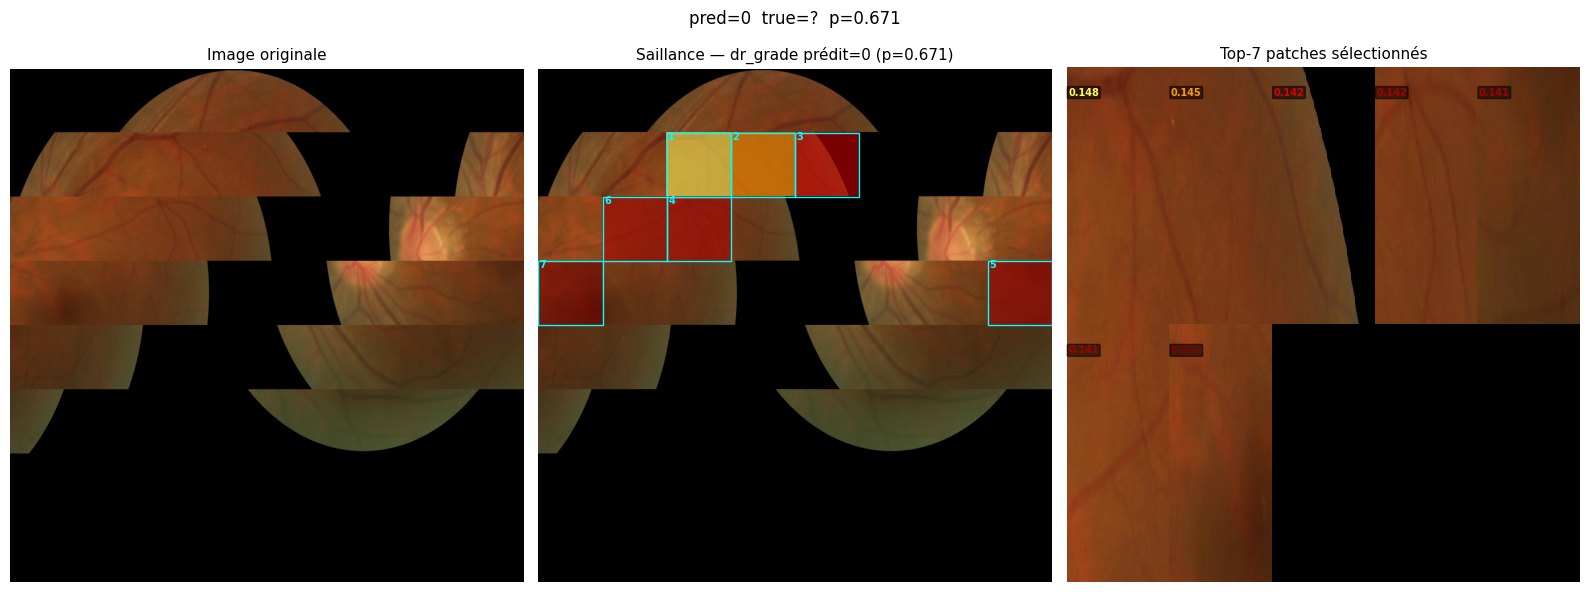

  Sauvegardé : /kaggle/working/saliency/ips_ddr_v1_saliency_00_img456.png
  Patches    : /kaggle/working/saliency/ips_ddr_v1_patches_00_img456.npy
  Sauvegardé : /kaggle/working/saliency/ips_ddr_v1_saliency_01_img102.png
  Patches    : /kaggle/working/saliency/ips_ddr_v1_patches_01_img102.npy
  Sauvegardé : /kaggle/working/saliency/ips_ddr_v1_saliency_02_img1126.png
  Patches    : /kaggle/working/saliency/ips_ddr_v1_patches_02_img1126.npy
  Sauvegardé : /kaggle/working/saliency/ips_ddr_v1_saliency_03_img1003.png
  Patches    : /kaggle/working/saliency/ips_ddr_v1_patches_03_img1003.npy
  Sauvegardé : /kaggle/working/saliency/ips_ddr_v1_saliency_04_img914.png
  Patches    : /kaggle/working/saliency/ips_ddr_v1_patches_04_img914.npy
CSV : /kaggle/working/saliency/ips_ddr_v1_saliency.csv  (35 lignes)


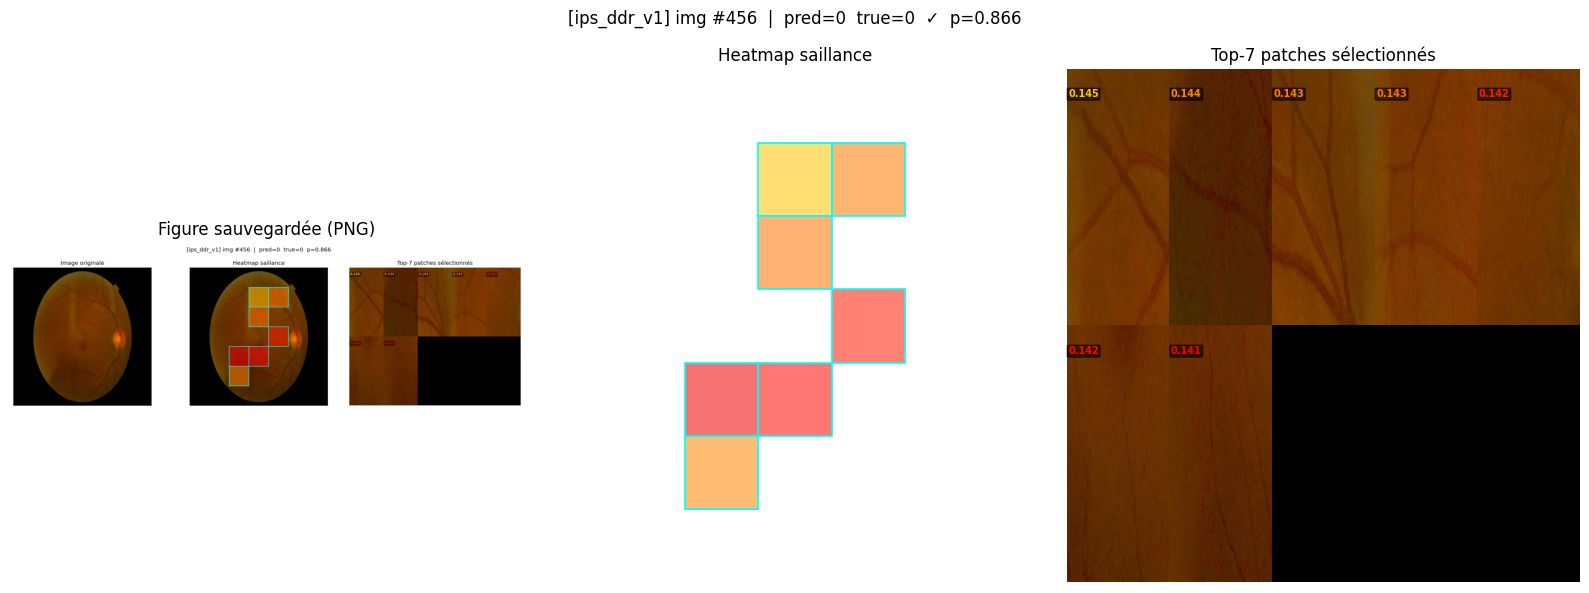

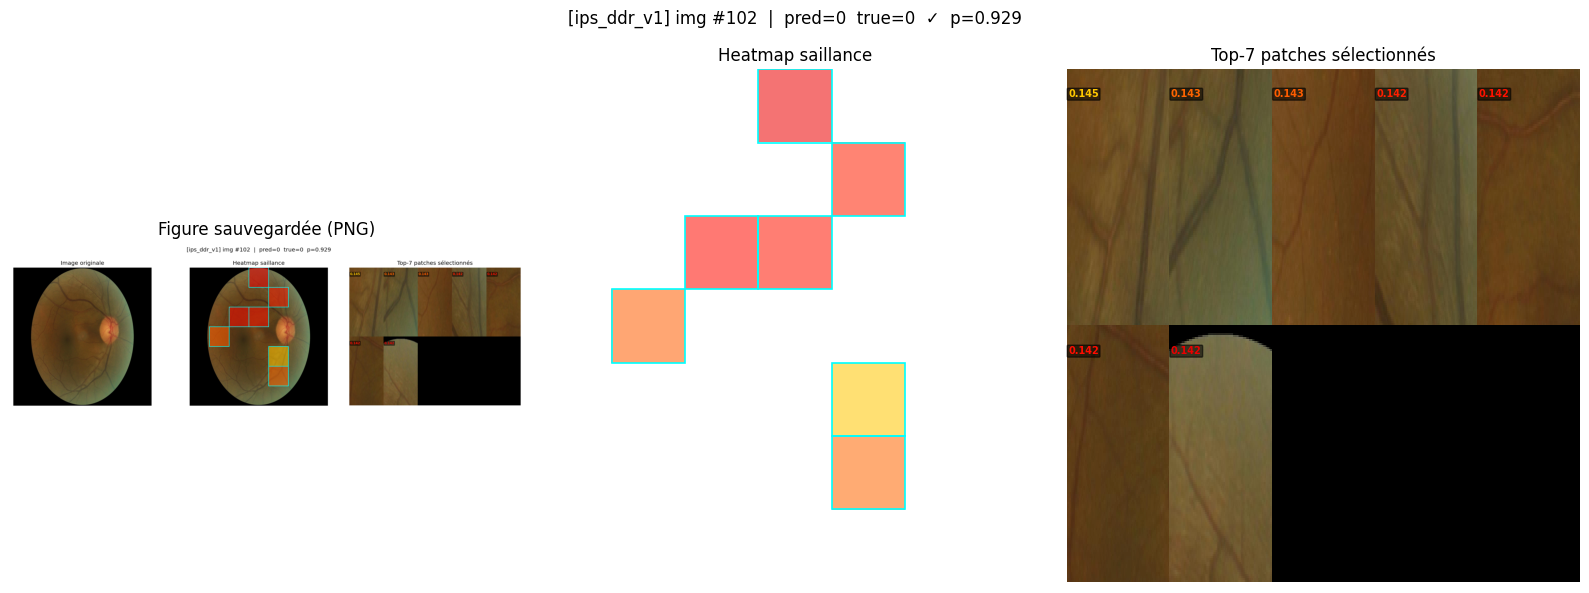

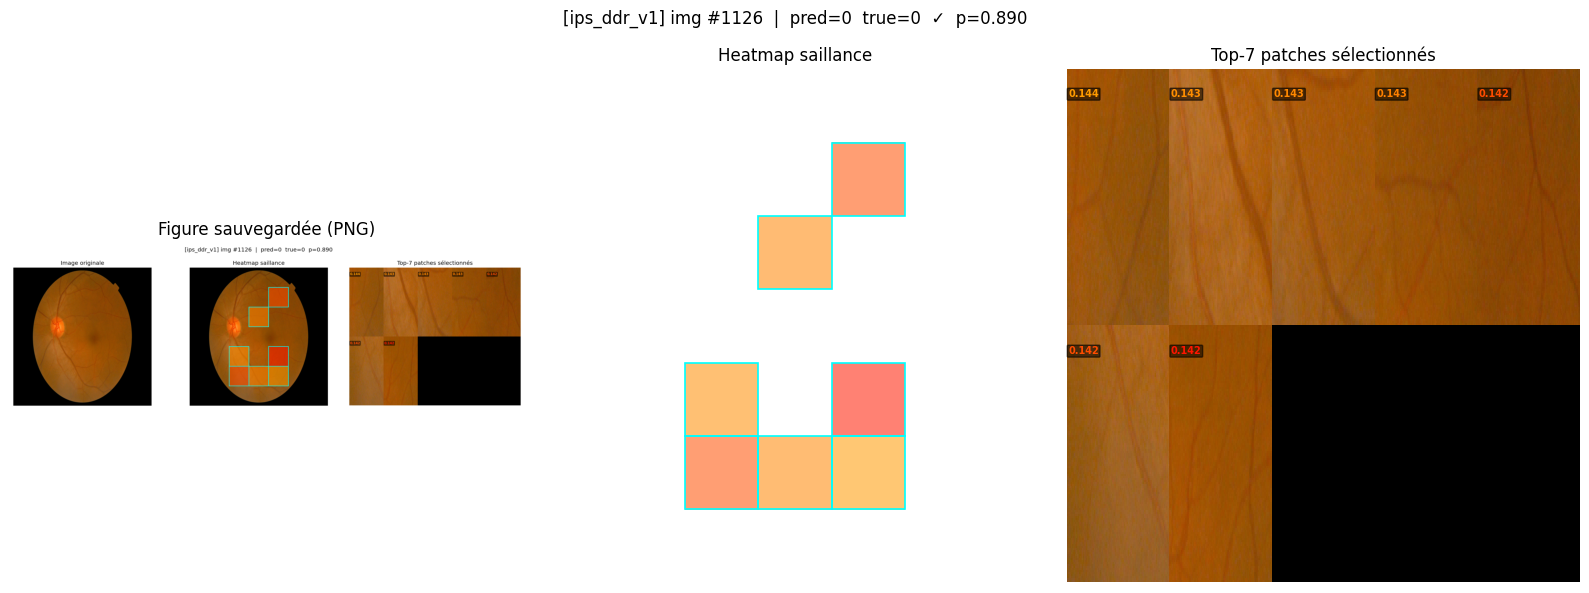

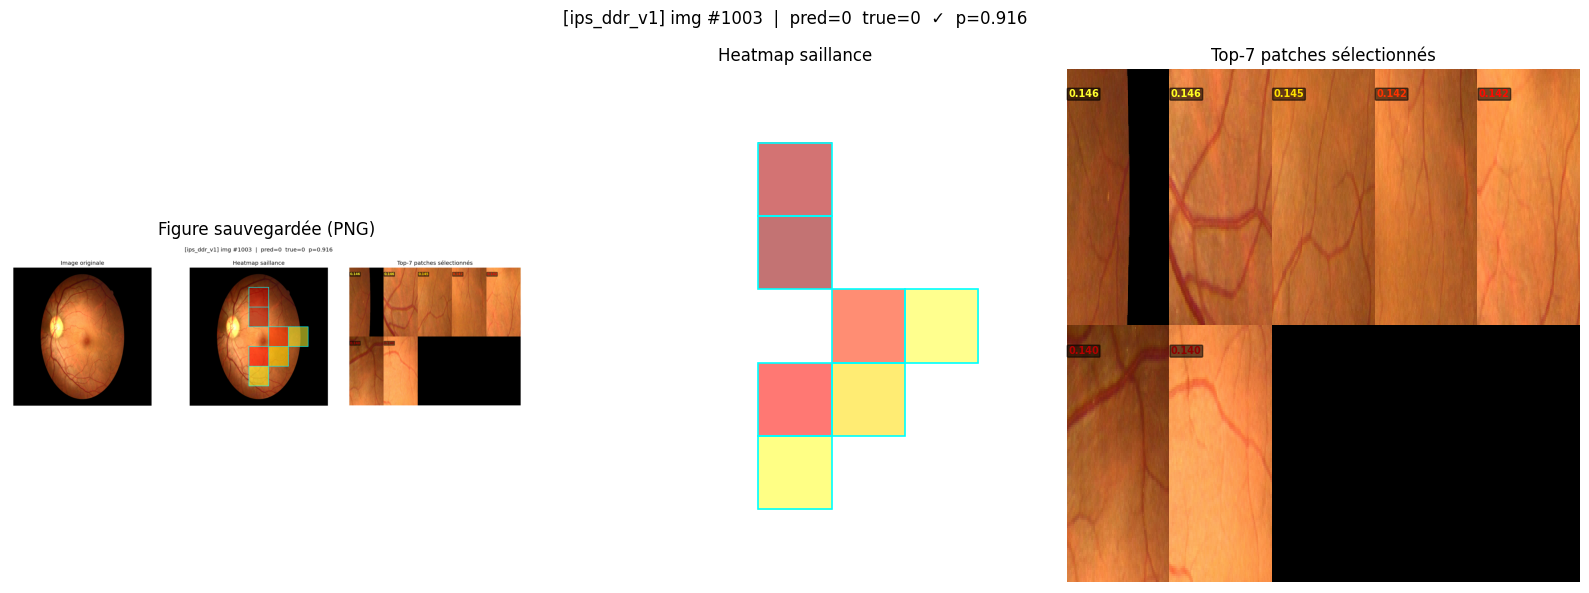

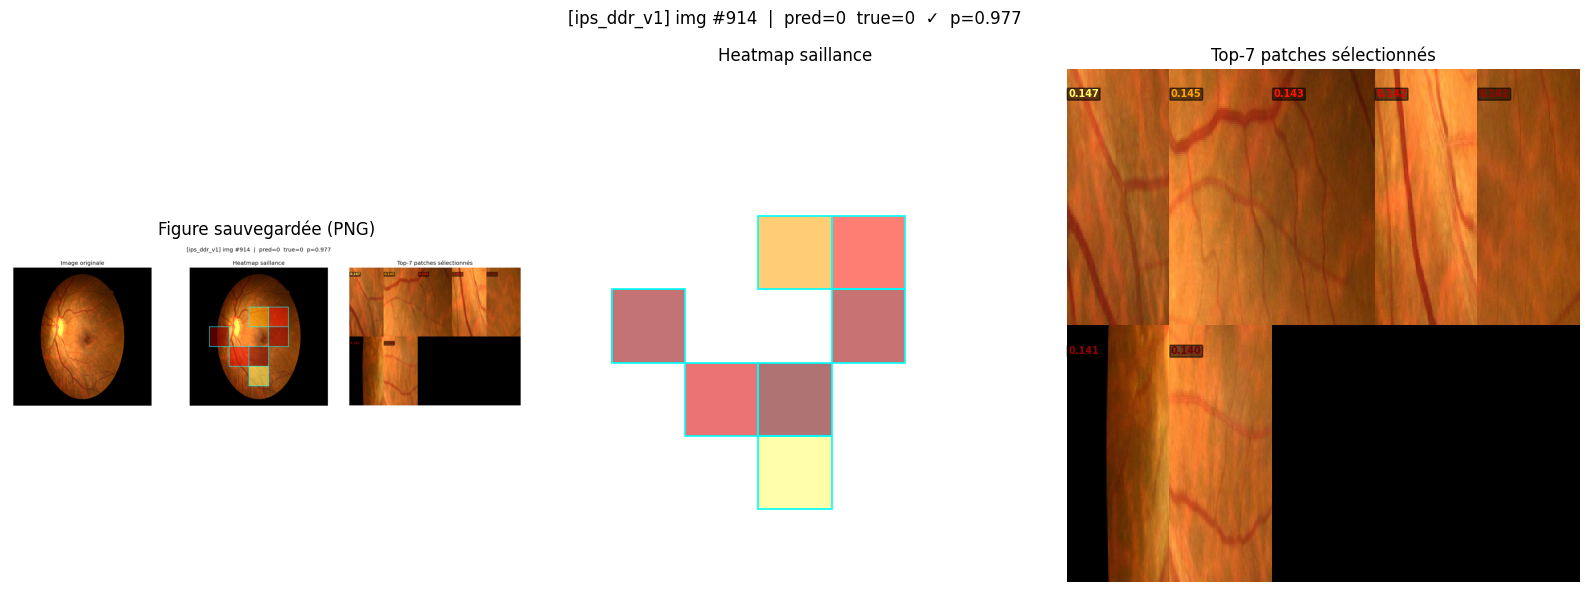

In [81]:
# ============================================================
# Cellule 3b — Enregistrement DDR dans DataFactory
#              + patch Logger pour kappa (QWK) et f1-macro
# ============================================================
from sklearn.metrics import cohen_kappa_score, f1_score


# ── 1. Enregistrement DDR ─────────────────────────────────
DataFactory._registry["ddr"] = DDRDataset


# ── 2. Patch Logger.compute_metric ───────────────────────
# Ajoute le support de : kappa (QWK), f1 (macro), accuracy (multi-classe)
# Remplace la méthode originale sans toucher aux autres méthodes.

_original_compute_metric = Logger.compute_metric


def _patched_compute_metric(self):
    for task in self.task_dict.values():
        t      = task['name']
        losses = self.losses_it[t]
        self.losses_epoch[t].append(np.mean(losses))

        requested = task['metric']
        if isinstance(requested, str):
            requested = [requested]

        y_true     = np.array(self.y_trues[t])
        y_pred_raw = np.array(self.y_preds[t])

        epoch_metrics = {}
        for current_metric in requested:

            if current_metric == 'accuracy':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = accuracy_score(y_true, y_pred)

            elif current_metric == 'kappa':
                # Quadratic Weighted Kappa — métrique principale DDR
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                try:
                    epoch_metrics[current_metric] = cohen_kappa_score(
                        y_true, y_pred, weights='quadratic')
                except Exception:
                    epoch_metrics[current_metric] = 0.0

            elif current_metric == 'f1':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = f1_score(
                    y_true, y_pred,
                    average='macro', zero_division=0)

            elif current_metric == 'auc':
                scores = (y_pred_raw[:, 1]
                          if y_pred_raw.ndim == 2 else y_pred_raw)
                epoch_metrics[current_metric] = roc_auc_score(y_true, scores)

            elif current_metric == 'precision':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = precision_score(
                    y_true, y_pred, average='macro', zero_division=0)

            elif current_metric == 'recall':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = recall_score(
                    y_true, y_pred, average='macro', zero_division=0)

            elif current_metric == 'multilabel_accuracy':
                y_pred  = np.where(y_pred_raw >= 0.5, 1., 0.)
                correct = np.all(y_pred == y_true, axis=-1).sum()
                epoch_metrics[current_metric] = correct / len(y_true)

        self.metrics[t].append(epoch_metrics)

        # Réinitialisation pour la prochaine époque
        self.losses_it[t] = []
        self.y_preds[t]   = []
        self.y_trues[t]   = []


# Appliquer le patch
Logger.compute_metric = _patched_compute_metric
print("Logger.compute_metric patché ✓  (kappa QWK + f1 macro)")


# ── 3. Patch Logger.update ───────────────────────────────
# Pour softmax multi-classe : stocker le vecteur de probs entier (pas juste [:, 1])

_original_update = Logger.update


def _patched_update(self, next_loss, next_y_pred, next_y_true):
    for task in self.task_dict.values():
        t      = task['name']
        t_metr = task['metric']
        if isinstance(t_metr, str):
            t_metr = [t_metr]

        self.losses_it[t].append(next_loss[t])

        raw = next_y_pred[t]   # shape : (B, n_class) après softmax

        # Stocker toujours le vecteur complet — compute_metric fera argmax
        if isinstance(raw, np.ndarray):
            self.y_preds[t].extend(raw.tolist())
        else:
            self.y_preds[t].extend(raw)

        if isinstance(next_y_true[t], np.ndarray):
            self.y_trues[t].extend(next_y_true[t].tolist())
        else:
            self.y_trues[t].extend(
                next_y_true[t] if hasattr(next_y_true[t], '__iter__')
                else [next_y_true[t]])


Logger.update = _patched_update
print("Logger.update patché ✓  (stockage vecteur probs complet)")


# ── Vérification finale ───────────────────────────────────
print(f"\nDataFactory registry : {list(DataFactory._registry.keys())}")

# Test rapide du Logger patché
log_test = Logger(ddr_conf.tasks)
fake_loss  = {'dr_grade': 1.2}
fake_pred  = {'dr_grade': np.array([[0.7, 0.1, 0.1, 0.05, 0.05],
                                     [0.1, 0.1, 0.6, 0.1,  0.1 ]])}
fake_label = {'dr_grade': np.array([0, 2])}
log_test.update(fake_loss, fake_pred, fake_label)
log_test.compute_metric()
print(f"Logger patché — metrics test : {log_test.metrics['dr_grade']}")



# ============================================================
# Cellule 6 — Runner DDR
# ============================================================
import torch, numpy as np

torch.manual_seed(ddr_conf.seed)
np.random.seed(ddr_conf.seed)

factory = DataFactory(ddr_conf, dataset="ddr")
train_loader, val_loader = factory.loaders()

net    = IPSNet(DEVICE, ddr_conf)
engine = UniversalEngine(
    net, ddr_conf, DEVICE, run_name="ips_ddr_v1")
engine.summary()

history = engine.fit(train_loader, val_loader)
#engine.summary()
engine.save("/kaggle/working/ips_ddr_v1.pt")
engine.save_history("/kaggle/working/ips_ddr_v1_history.json")
engine.log_experiment("/kaggle/working")

# ── Inférence + saillance ────────────────────────────────
sample    = factory.test_data[0]
img_check = sample['input']
result    = engine.predict(img_check, return_patches=True)
print(f"Probs : {result['probs']}")
print(f"Label prédit : {result['label']} | Label réel : {sample['dr_grade']}")
#engine.show_saliency(img_check, result)

save_dir, csv_path = engine.save_saliency(
    dataset  = factory.test_data,
    save_dir = "/kaggle/working/saliency",
    n_images = 5,
    seed     = 42
)

#engine.show_saliency_from_disk(save_dir=save_dir)   